In [14]:
# Check GPU details
!nvidia-smi

import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

Tue Oct  6 00:18:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.91.07              Driver Version: 595.91.07      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        Off |   00000000:01:00.0 Off |                  N/A |
|  0%   73C    P8             17W /  170W |     242MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
import os

!git clone https://github.com/zrguo/MPLMM

# Install requirements if provided
if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt || echo "Ignoring conflicts..."

Cloning into 'MPLMM'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 30 (delta 8), reused 27 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 148.35 KiB | 2.03 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [16]:
%cd MLProjectVidit/

[Errno 2] No such file or directory: 'MLProjectVidit/'
/home/cse/Desktop/MLProjectVidit/MPLMM


In [ ]:
from pathlib import Path
import pickle
import subprocess
import sys
import zipfile
import urllib.request

# Project root: the folder containing MPLMM/ and dataset/
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"
DATASET_DIR.mkdir(exist_ok=True)

ARCHIVE_URL = (
    "https://www.dropbox.com/sh/hyzpgx1hp9nj37s/"
    "AADfY2s7gD_MkR76m03KS0K1a/Archive.zip?dl=1"
)
ARCHIVE_PATH = DATASET_DIR / "Archive.zip"

# Download the archive only if the expected dataset files are missing
expected_files = [
    "mosi_data.pkl",
    "mosi_data_noalign.pkl",
    "mosei_senti_data.pkl",
    "mosei_senti_data_noalign.pkl",
    "iemocap_data.pkl",
    "iemocap_data_noalign.pkl",
]

missing_files = [
    name for name in expected_files
    if not (DATASET_DIR / name).exists()
]

if missing_files:
    print("Downloading dataset archive...")
    urllib.request.urlretrieve(ARCHIVE_URL, ARCHIVE_PATH)

    print("Extracting dataset files...")
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as archive:
        archive.extractall(DATASET_DIR)

    ARCHIVE_PATH.unlink(missing_ok=True)

# Verify the downloaded datasets
def inspect_dataset(filename):
    dataset_path = DATASET_DIR / filename

    if not dataset_path.exists():
        print(f"{filename}: not found")
        return

    try:
        with dataset_path.open("rb") as file:
            data = pickle.load(file)

        print(f"\n{filename}")
        for split in ["train", "valid", "test"]:
            print(f"{split}:")
            for key in ["text", "audio", "vision", "labels"]:
                print(f"  {key}: {data[split][key].shape}")

    except Exception as error:
        print(f"{filename}: Error loading dataset: {error}")

for filename in expected_files:
    inspect_dataset(filename)


mosi_data.pkl
train:
  text: (1284, 50, 300)
  audio: (1284, 50, 5)
  vision: (1284, 50, 20)
  labels: (1284, 1, 1)
valid:
  text: (229, 50, 300)
  audio: (229, 50, 5)
  vision: (229, 50, 20)
  labels: (229, 1, 1)
test:
  text: (686, 50, 300)
  audio: (686, 50, 5)
  vision: (686, 50, 20)
  labels: (686, 1, 1)

mosi_data_noalign.pkl
train:
  text: (1284, 50, 300)
  audio: (1284, 375, 5)
  vision: (1284, 500, 20)
  labels: (1284, 1, 1)
valid:
  text: (229, 50, 300)
  audio: (229, 375, 5)
  vision: (229, 500, 20)
  labels: (229, 1, 1)
test:
  text: (686, 50, 300)
  audio: (686, 375, 5)
  vision: (686, 500, 20)
  labels: (686, 1, 1)

mosei_senti_data.pkl
train:
  text: (16265, 50, 300)
  audio: (16265, 50, 74)
  vision: (16265, 50, 35)
  labels: (16265, 1, 1)
valid:
  text: (1869, 50, 300)
  audio: (1869, 50, 74)
  vision: (1869, 50, 35)
  labels: (1869, 1, 1)
test:
  text: (4643, 50, 300)
  audio: (4643, 50, 74)
  vision: (4643, 50, 35)
  labels: (4643, 1, 1)


In [ ]:
%cd MPLMM/
!pwd

/home/cse/Desktop/MLProjectVidit/MPLMM
/home/cse/Desktop/MLProjectVidit/MPLMM


In [ ]:
import sys

print("Notebook Python:", sys.executable)
!{sys.executable} -m pip install --upgrade h5py

Notebook Python: /home/cse/miniconda3/bin/python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 16.0 MB/s  0:00:00 eta 0:00:01


In [ ]:
import os
import sys

os.makedirs("./pretrained", exist_ok=True)

!{sys.executable} main.py \
    --dataset mosi \
    --data_path dataset/mosi_data.pkl \
    --drop_rate 0.7 \
    --name smoke.pt \
    --num_epochs 2

--------------------------------------------------
Epoch  1 | Time 10.5429 sec | Valid Loss 2.0329 | Test Loss 1.6821
--------------------------------------------------
Saved model at smoke.pt
--------------------------------------------------
Epoch  2 | Time 2.5115 sec | Valid Loss 1.4356 | Test Loss 1.2416
--------------------------------------------------
Saved model at smoke.pt
MAE:  1.435573
Correlation Coefficient:  0.28315996888380257
mult_acc_7:  0.18777292576419213
mult_acc_5:  0.21397379912663755
F1 score:  0.5864969135802469
Accuracy:  0.5740740740740741


In [ ]:
import os
import sys

print("Python used by notebook:", sys.executable)

os.makedirs("./pretrained", exist_ok=True)

!{sys.executable} main.py \
    --dataset mosei \
    --data_path dataset/mosei_senti_data.pkl \
    --drop_rate 0 \
    --name ./pretrained/mosei.pt

Python used by notebook: /home/cse/miniconda3/bin/python


Epoch  1 | Batch  30/254 | Time/Batch(ms) 139.23 | Train Loss 1.0586
Epoch  1 | Batch  60/254 | Time/Batch(ms) 86.96 | Train Loss 1.0841
Epoch  1 | Batch  90/254 | Time/Batch(ms) 87.22 | Train Loss 0.9709
Epoch  1 | Batch 120/254 | Time/Batch(ms) 87.35 | Train Loss 0.9338
Epoch  1 | Batch 150/254 | Time/Batch(ms) 87.33 | Train Loss 0.6908
Epoch  1 | Batch 180/254 | Time/Batch(ms) 88.27 | Train Loss 0.6927
Epoch  1 | Batch 210/254 | Time/Batch(ms) 89.38 | Train Loss 0.7209
Epoch  1 | Batch 240/254 | Time/Batch(ms) 89.90 | Train Loss 0.6775
--------------------------------------------------
Epoch  1 | Time 28.9011 sec | Valid Loss 0.7548 | Test Loss 0.8212
--------------------------------------------------
Saved model at ./pretrained/mosei.pt
Epoch  2 | Batch  30/254 | Time/Batch(ms) 95.30 | Train Loss 0.9922
Epoch  2 | Batch  60/254 | Time/Batch(ms) 91.68 | Train Loss 1.0177
Epoch  2 | Batch  90/254 | Time/Batch(ms) 91.71 | Train Loss 0.9543
Epoch  2 | Batch 120/254 | Time/Batch(ms) 93.

In [3]:
%cd MPLMM/
!pwd

/home/cse/Desktop/MLProjectVidit/MPLMM
/home/cse/Desktop/MLProjectVidit/MPLMM


In [6]:
import os
import sys
import subprocess

os.makedirs("results", exist_ok=True)

print("Training configuration:")
print("  Batch size: 64")
print("  Learning rate: 1e-3")
print("  Optimizer: Adam")
print("  Epochs: 30")
print("  Missing-modality rate: 0.7")
print("  Log interval: 1 batch")

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--pretrained_model", "pretrained/mosei.pt",
        "--dataset", "mosi",
        "--data_path", "dataset/mosi_data.pkl",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "30",
        "--seed", "1111",
        "--name", "results/mosi_stage2_seed_1111_30ep.pt",
        "--log_interval", "1",
    ],
    check=True,
)

Training configuration:
  Batch size: 64
  Learning rate: 1e-3
  Optimizer: Adam
  Epochs: 30
  Missing-modality rate: 0.7
  Log interval: 1 batch
Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Epoch  1 | Batch   1/ 20 | Time/Batch(ms) 487.91 | Train Loss 1.2415
Epoch  1 | Batch   2/ 20 | Time/Batch(ms) 111.57 | Train Loss 1.4802
Epoch  1 | Batch   3/ 20 | Time/Batch(ms) 113.93 | Train Loss 1.4421
Epoch  1 | Batch   4/ 20 | Time/Batch(ms) 115.19 | Train Loss 1.2839
Epoch  1 | Batch   5/ 20 | Time/Batch(ms) 115.42 | Train Loss 1.2728
Epoch  1 | Batch   6/ 20 | Time/Batch(ms) 113.03 | Train Loss 1.2796
Epoch  1 | Batch   7/ 20 | Time/Batch(ms) 113.51 | Train Loss 1.1954
Epoch  1 | Batch   8/ 20 | Time/Batch(ms) 115.87 | Train Loss 1.1970
Epoch  1 | Batch   9/ 20 | Time/Batch(ms) 112.85 | Train Loss 1.3524
Epoch  1 | Batch  10/ 20 | Time/Batch(ms) 116.14 | Train Loss 1.1918
Epoch  1 | Batch  11/ 20 | Time/Batch(ms) 115.49 | Train Loss 1.1854
Epoch  1 | Batch  12/ 20 | Time/Batch(ms) 118.97 | Train Loss 1.2591
Epoch  1 | Batch  13/ 20 | Time/Batch(ms) 116.95 | Train Loss 1.1820
Epoch  1 | Batch  14/ 20 | Time/Batch(ms) 112.18 | Train Loss 1.2930
Epoch  1 | Batch  15/ 20 | Time/Ba

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--pretrained_model', 'pretrained/mosei.pt', '--dataset', 'mosi', '--data_path', 'dataset/mosi_data.pkl', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '30', '--seed', '1111', '--name', 'results/mosi_stage2_seed_1111_30ep.pt', '--log_interval', '1'], returncode=0)

In [7]:
import os
import sys
import subprocess

os.makedirs("results", exist_ok=True)

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--pretrained_model", "pretrained/mosei.pt",
        "--dataset", "mosei",
        "--data_path", "dataset/mosei_senti_data.pkl",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "30",
        "--seed", "1111",
        "--name", "results/mosei_stage2_seed_1111_30ep.pt",
        "--log_interval", "1",
    ],
    check=True,
)

Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Epoch  1 | Batch   1/255 | Time/Batch(ms) 659.52 | Train Loss 0.7416
Epoch  1 | Batch   2/255 | Time/Batch(ms) 200.22 | Train Loss 0.4886
Epoch  1 | Batch   3/255 | Time/Batch(ms) 200.72 | Train Loss 0.4706
Epoch  1 | Batch   4/255 | Time/Batch(ms) 202.99 | Train Loss 0.6880
Epoch  1 | Batch   5/255 | Time/Batch(ms) 208.42 | Train Loss 0.9574
Epoch  1 | Batch   6/255 | Time/Batch(ms) 200.89 | Train Loss 1.1124
Epoch  1 | Batch   7/255 | Time/Batch(ms) 204.16 | Train Loss 0.8854
Epoch  1 | Batch   8/255 | Time/Batch(ms) 203.17 | Train Loss 1.0740
Epoch  1 | Batch   9/255 | Time/Batch(ms) 200.06 | Train Loss 1.0265
Epoch  1 | Batch  10/255 | Time/Batch(ms) 203.79 | Train Loss 0.8000
Epoch  1 | Batch  11/255 | Time/Batch(ms) 207.40 | Train Loss 1.1569
Epoch  1 | Batch  12/255 | Time/Batch(ms) 202.58 | Train Loss 1.1089
Epoch  1 | Batch  13/255 | Time/Batch(ms) 204.96 | Train Loss 1.1967
Epoch  1 | Batch  14/255 | Time/Batch(ms) 204.10 | Train Loss 0.9011
Epoch  1 | Batch  15/255 | Time/Ba

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--pretrained_model', 'pretrained/mosei.pt', '--dataset', 'mosei', '--data_path', 'dataset/mosei_senti_data.pkl', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '30', '--seed', '1111', '--name', 'results/mosei_stage2_seed_1111_30ep.pt', '--log_interval', '1'], returncode=0)

In [4]:
import os
import sys
import subprocess

os.makedirs("results", exist_ok=True)

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--pretrained_model", "pretrained/mosei.pt",
        "--dataset", "sims",
        "--data_path", "dataset/sims_data.pkl",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "30",
        "--seed", "1111",
        "--name", "results/sims_stage2_seed_1111_30ep.pt",
        "--log_interval", "1",
    ],
    check=True,
)

Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [39] is 39 which does not match the computed number of elements 400. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (400,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [400] is 400 which does not match the computed number of elements 416. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (416,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: U

Epoch  1 | Batch   1/ 22 | Time/Batch(ms) 956.18 | Train Loss 0.6483
Epoch  1 | Batch   2/ 22 | Time/Batch(ms) 335.44 | Train Loss 0.6710
Epoch  1 | Batch   3/ 22 | Time/Batch(ms) 335.92 | Train Loss 0.6353
Epoch  1 | Batch   4/ 22 | Time/Batch(ms) 336.93 | Train Loss 0.5389
Epoch  1 | Batch   5/ 22 | Time/Batch(ms) 337.80 | Train Loss 0.6657
Epoch  1 | Batch   6/ 22 | Time/Batch(ms) 336.84 | Train Loss 0.5665
Epoch  1 | Batch   7/ 22 | Time/Batch(ms) 336.50 | Train Loss 0.5846
Epoch  1 | Batch   8/ 22 | Time/Batch(ms) 338.98 | Train Loss 0.6187
Epoch  1 | Batch   9/ 22 | Time/Batch(ms) 334.24 | Train Loss 0.6158
Epoch  1 | Batch  10/ 22 | Time/Batch(ms) 336.54 | Train Loss 0.5765
Epoch  1 | Batch  11/ 22 | Time/Batch(ms) 335.97 | Train Loss 0.5136
Epoch  1 | Batch  12/ 22 | Time/Batch(ms) 335.57 | Train Loss 0.6157
Epoch  1 | Batch  13/ 22 | Time/Batch(ms) 338.76 | Train Loss 0.5469
Epoch  1 | Batch  14/ 22 | Time/Batch(ms) 335.91 | Train Loss 0.5835
Epoch  1 | Batch  15/ 22 | Time/Ba

/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([24, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: Using a target size (torch.Size([9])) that is different to the input size (torch.Size([9, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


--------------------------------------------------
Epoch  1 | Time 9.8629 sec | Valid Loss 0.5917 | Test Loss 0.5922
--------------------------------------------------
Saved model at results/sims_stage2_seed_1111_30ep.pt
Epoch  2 | Batch   1/ 22 | Time/Batch(ms) 677.79 | Train Loss 0.6217
Epoch  2 | Batch   2/ 22 | Time/Batch(ms) 337.46 | Train Loss 0.6657
Epoch  2 | Batch   3/ 22 | Time/Batch(ms) 341.82 | Train Loss 0.6335
Epoch  2 | Batch   4/ 22 | Time/Batch(ms) 338.87 | Train Loss 0.5326
Epoch  2 | Batch   5/ 22 | Time/Batch(ms) 338.60 | Train Loss 0.6684
Epoch  2 | Batch   6/ 22 | Time/Batch(ms) 337.28 | Train Loss 0.5648
Epoch  2 | Batch   7/ 22 | Time/Batch(ms) 338.74 | Train Loss 0.5770
Epoch  2 | Batch   8/ 22 | Time/Batch(ms) 340.16 | Train Loss 0.6033
Epoch  2 | Batch   9/ 22 | Time/Batch(ms) 337.72 | Train Loss 0.6167
Epoch  2 | Batch  10/ 22 | Time/Batch(ms) 336.88 | Train Loss 0.5697
Epoch  2 | Batch  11/ 22 | Time/Batch(ms) 337.98 | Train Loss 0.5147
Epoch  2 | Batch  12

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--pretrained_model', 'pretrained/mosei.pt', '--dataset', 'sims', '--data_path', 'dataset/sims_data.pkl', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '30', '--seed', '1111', '--name', 'results/sims_stage2_seed_1111_30ep.pt', '--log_interval', '1'], returncode=0)

In [13]:
from pathlib import Path

iemocap_root = Path("dataset/iemocap/IEMOCAP_features_2021")

required_files = [
    iemocap_root / "A/comparE.h5",
    iemocap_root / "A/comparE_mean_std.h5",
    iemocap_root / "V/denseface.h5",
    iemocap_root / "L/bert_large.h5",
    iemocap_root / "target/1/trn_label.npy",
    iemocap_root / "target/1/val_label.npy",
    iemocap_root / "target/1/tst_label.npy",
]

for path in required_files:
    print(f"{path}: {'OK' if path.exists() else 'MISSING'}")

missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing IEMOCAP files:\n" + "\n".join(missing)
    )

dataset/iemocap/IEMOCAP_features_2021/A/comparE.h5: OK
dataset/iemocap/IEMOCAP_features_2021/A/comparE_mean_std.h5: OK
dataset/iemocap/IEMOCAP_features_2021/V/denseface.h5: OK
dataset/iemocap/IEMOCAP_features_2021/L/bert_large.h5: OK
dataset/iemocap/IEMOCAP_features_2021/target/1/trn_label.npy: OK
dataset/iemocap/IEMOCAP_features_2021/target/1/val_label.npy: OK
dataset/iemocap/IEMOCAP_features_2021/target/1/tst_label.npy: OK


In [3]:
import os
import sys
import subprocess

os.makedirs("results", exist_ok=True)

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--pretrained_model", "pretrained/mosei.pt",
        "--dataset", "iemocap",
        "--data_path", "dataset/iemocap/IEMOCAP_features_2021",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "30",
        "--seed", "1111",
        "--name", "results/iemocap_stage2_seed_1111_30ep.pt",
        "--log_interval", "1",
    ],
    check=True,
)

Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [22] is 22 which does not match the computed number of elements 350. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (350,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [350] is 350 which does not match the computed number of elements 366. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (366,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Epoch  1 | Batch   1/ 70 | Time/Batch(ms) 9138.71 | Train Loss 1.4404
Epoch  1 | Batch   2/ 70 | Time/Batch(ms) 4444.86 | Train Loss 1.4326
Epoch  1 | Batch   3/ 70 | Time/Batch(ms) 4369.55 | Train Loss 1.3881
Epoch  1 | Batch   4/ 70 | Time/Batch(ms) 4405.36 | Train Loss 1.3691
Epoch  1 | Batch   5/ 70 | Time/Batch(ms) 4479.31 | Train Loss 1.3865
Epoch  1 | Batch   6/ 70 | Time/Batch(ms) 4370.19 | Train Loss 1.3390
Epoch  1 | Batch   7/ 70 | Time/Batch(ms) 4346.94 | Train Loss 1.3534
Epoch  1 | Batch   8/ 70 | Time/Batch(ms) 4223.76 | Train Loss 1.3448
Epoch  1 | Batch   9/ 70 | Time/Batch(ms) 4336.22 | Train Loss 1.3770
Epoch  1 | Batch  10/ 70 | Time/Batch(ms) 4269.61 | Train Loss 1.3502
Epoch  1 | Batch  11/ 70 | Time/Batch(ms) 4156.14 | Train Loss 1.3792
Epoch  1 | Batch  12/ 70 | Time/Batch(ms) 4322.27 | Train Loss 1.3697
Epoch  1 | Batch  13/ 70 | Time/Batch(ms) 4184.75 | Train Loss 1.3892
Epoch  1 | Batch  14/ 70 | Time/Batch(ms) 4167.12 | Train Loss 1.3421
Epoch  1 | Batch  15

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--pretrained_model', 'pretrained/mosei.pt', '--dataset', 'iemocap', '--data_path', 'dataset/iemocap/IEMOCAP_features_2021', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '30', '--seed', '1111', '--name', 'results/iemocap_stage2_seed_1111_30ep.pt', '--log_interval', '1'], returncode=0)

In [2]:
!pwd
%cd MPLMM/

/home/cse/Desktop/MLProjectVidit
/home/cse/Desktop/MLProjectVidit/MPLMM


In [5]:
import os
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

from src.utils import get_data


# Table columns are the AVAILABLE modalities.
#
# Internal model mapping from PromptModel.get_complete_data():
#   0 -> text missing       -> {a,v} available
#   1 -> audio missing      -> {v,t} available
#   2 -> vision missing     -> {a,t} available
#   3 -> text + audio miss  -> {v} available
#   4 -> text + vision miss -> {a} available
#   5 -> audio + vision miss-> {t} available
CASE_MODES = {
    "{a,v}": 0,
    "{v,t}": 1,
    "{a,t}": 2,
    "{v}": 3,
    "{a}": 4,
    "{t}": 5,
}


def build_test_loader(dataset_name, data_path, batch_size=64):
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Dataset not found: {data_path}")

    args = SimpleNamespace(
        dataset=dataset_name,
        data_path=data_path,
        drop_rate=0.0,
    )

    dataset = get_data(
        args,
        split="test",
        full_data=True,
    )

    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": False,
    }

    # Required for variable-length IEMOCAP sequences.
    if dataset_name == "iemocap":
        loader_kwargs["collate_fn"] = dataset.collate_fn

    return DataLoader(dataset, **loader_kwargs)


def evaluate_case(model, dataset_name, loader, mode):
    device = next(model.parameters()).device

    all_predictions = []
    all_truths = []

    model.eval()

    with torch.no_grad():
        for batch_x, batch_y, _ in loader:
            text, audio, vision = batch_x

            text = text.to(device)
            audio = audio.to(device)
            vision = vision.to(device)

            # Force one fixed missing-modality case for this entire batch.
            missing_modes = torch.full(
                (text.size(0),),
                mode,
                dtype=torch.long,
                device=device,
            )

            output = model(
                text,
                audio,
                vision,
                missing_modes,
            )

            all_predictions.append(output.detach().cpu())
            all_truths.append(batch_y.detach().cpu())

    predictions = torch.cat(all_predictions)
    truths = torch.cat(all_truths)

    if dataset_name == "iemocap":
        predicted_labels = predictions.view(-1, 4).argmax(dim=1).numpy()
        true_labels = truths.view(-1).long().numpy()

        accuracy = accuracy_score(true_labels, predicted_labels)
        f1 = f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        )

    else:
        predictions = predictions.view(-1).numpy()
        truths = truths.view(-1).numpy()

        predicted_labels = predictions >= 0
        true_labels = truths >= 0

        accuracy = accuracy_score(true_labels, predicted_labels)
        f1 = f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        )

    return {
        "ACC": float(accuracy * 100),
        "F1": float(f1 * 100),
    }


def evaluate_dataset(
    dataset_name,
    data_path,
    checkpoint_path,
    batch_size=64,
):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
    model = model.to(device)
    model.eval()

    loader = build_test_loader(
        dataset_name,
        data_path,
        batch_size=batch_size,
    )

    results = {}

    for case_name, mode in CASE_MODES.items():
        print(
            f"Evaluating {dataset_name} "
            f"{case_name} using mode {mode}..."
        )

        results[case_name] = evaluate_case(
            model=model,
            dataset_name=dataset_name,
            loader=loader,
            mode=mode,
        )

    results["Avg."] = {
        "ACC": float(np.mean([
            results[case]["ACC"]
            for case in CASE_MODES
        ])),
        "F1": float(np.mean([
            results[case]["F1"]
            for case in CASE_MODES
        ])),
    }

    return results

In [6]:
def results_to_row(dataset_name, method_name, results):
    row = {
        "Dataset": dataset_name,
        "Method": method_name,
    }

    for case_name in CASE_MODES:
        row[f"{case_name} ACC"] = results[case_name]["ACC"]
        row[f"{case_name} F1"] = results[case_name]["F1"]

    row["Avg. ACC"] = results["Avg."]["ACC"]
    row["Avg. F1"] = results["Avg."]["F1"]

    return row


def print_results(dataset_name, results):
    print(f"\n{dataset_name}")
    print("-" * 70)

    for case_name in list(CASE_MODES) + ["Avg."]:
        print(
            f"{case_name:>6} | "
            f"ACC: {results[case_name]['ACC']:6.2f} | "
            f"F1: {results[case_name]['F1']:6.2f}"
        )

In [7]:
mosi_results = evaluate_dataset(
    dataset_name="mosi",
    data_path="dataset/mosi_data.pkl",
    checkpoint_path="results/mosi_stage2_seed_1111_30ep.pt",
)

print_results("MOSI", mosi_results)

Evaluating mosi {a,v} using mode 0...


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Evaluating mosi {v,t} using mode 1...
Evaluating mosi {a,t} using mode 2...
Evaluating mosi {v} using mode 3...
Evaluating mosi {a} using mode 4...
Evaluating mosi {t} using mode 5...

MOSI
----------------------------------------------------------------------
 {a,v} | ACC:  50.73 | F1:  44.26
 {v,t} | ACC:  69.24 | F1:  69.25
 {a,t} | ACC:  72.89 | F1:  72.96
   {v} | ACC:  45.34 | F1:  29.67
   {a} | ACC:  55.10 | F1:  52.15
   {t} | ACC:  71.72 | F1:  71.77
  Avg. | ACC:  60.84 | F1:  56.68


In [8]:
mosei_results = evaluate_dataset(
    dataset_name="mosei",
    data_path="dataset/mosei_senti_data.pkl",
    checkpoint_path="results/mosei_stage2_seed_1111_30ep.pt",
)

print_results("MOSEI", mosei_results)

Evaluating mosei {a,v} using mode 0...
Evaluating mosei {v,t} using mode 1...
Evaluating mosei {a,t} using mode 2...
Evaluating mosei {v} using mode 3...
Evaluating mosei {a} using mode 4...
Evaluating mosei {t} using mode 5...

MOSEI
----------------------------------------------------------------------
 {a,v} | ACC:  71.12 | F1:  59.55
 {v,t} | ACC:  79.17 | F1:  79.04
 {a,t} | ACC:  78.16 | F1:  77.97
   {v} | ACC:  70.92 | F1:  61.29
   {a} | ACC:  71.05 | F1:  59.09
   {t} | ACC:  78.70 | F1:  78.58
  Avg. | ACC:  74.85 | F1:  69.25


In [9]:
iemocap_results = evaluate_dataset(
    dataset_name="iemocap",
    data_path="dataset/iemocap/IEMOCAP_features_2021",
    checkpoint_path="results/iemocap_stage2_seed_1111_30ep.pt",
)

print_results("IEMOCAP", iemocap_results)

Evaluating iemocap {a,v} using mode 0...


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [66] is 66 which does not match the computed number of elements 350. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (350,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [350] is 350 which does not match the computed number of elements 366. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (366,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Evaluating iemocap {v,t} using mode 1...
Evaluating iemocap {a,t} using mode 2...
Evaluating iemocap {v} using mode 3...
Evaluating iemocap {a} using mode 4...
Evaluating iemocap {t} using mode 5...

IEMOCAP
----------------------------------------------------------------------
 {a,v} | ACC:  61.93 | F1:  59.86
 {v,t} | ACC:  62.31 | F1:  62.01
 {a,t} | ACC:  61.93 | F1:  61.59
   {v} | ACC:  54.55 | F1:  52.77
   {a} | ACC:  49.43 | F1:  45.39
   {t} | ACC:  50.95 | F1:  51.89
  Avg. | ACC:  56.85 | F1:  55.59


In [10]:
sims_results = evaluate_dataset(
    dataset_name="sims",
    data_path="dataset/sims_data.pkl",
    checkpoint_path="results/sims_stage2_seed_1111_30ep.pt",
)

print_results("CH-SIMS", sims_results)

Evaluating sims {a,v} using mode 0...


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [366] is 366 which does not match the computed number of elements 400. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (400,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [400] is 400 which does not match the computed number of elements 416. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (416,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Evaluating sims {v,t} using mode 1...
Evaluating sims {a,t} using mode 2...
Evaluating sims {v} using mode 3...
Evaluating sims {a} using mode 4...
Evaluating sims {t} using mode 5...

CH-SIMS
----------------------------------------------------------------------
 {a,v} | ACC:  54.27 | F1:  38.18
 {v,t} | ACC:  54.27 | F1:  38.18
 {a,t} | ACC:  54.27 | F1:  38.18
   {v} | ACC:  54.27 | F1:  38.18
   {a} | ACC:  54.27 | F1:  38.18
   {t} | ACC:  54.27 | F1:  38.18
  Avg. | ACC:  54.27 | F1:  38.18


In [11]:
all_rows = [
    results_to_row("MOSI", "Ours", mosi_results),
    results_to_row("IEMOCAP", "Ours", iemocap_results),
    results_to_row("CH-SIMS", "Ours", sims_results),
    results_to_row("MOSEI", "Ours", mosei_results),
]

table = pd.DataFrame(all_rows)

metric_columns = [
    "Dataset",
    "Method",
    "{a} ACC", "{a} F1",
    "{v} ACC", "{v} F1",
    "{t} ACC", "{t} F1",
    "{a,v} ACC", "{a,v} F1",
    "{a,t} ACC", "{a,t} F1",
    "{v,t} ACC", "{v,t} F1",
    "Avg. ACC", "Avg. F1",
]

table = table[metric_columns]
table.round(2)

,Dataset,Method,{a} ACC,{a} F1,{v} ACC,{v} F1,{t} ACC,{t} F1,"{a,v} ACC","{a,v} F1","{a,t} ACC","{a,t} F1","{v,t} ACC","{v,t} F1",Avg. ACC,Avg. F1
0,MOSI,Ours,55.10,52.15,45.34,29.67,71.72,71.77,50.73,44.26,72.89,72.96,69.24,69.25,60.84,56.68
1,IEMOCAP,Ours,49.43,45.39,54.55,52.77,50.95,51.89,61.93,59.86,61.93,61.59,62.31,62.01,56.85,55.59
2,CH-SIMS,Ours,54.27,38.18,54.27,38.18,54.27,38.18,54.27,38.18,54.27,38.18,54.27,38.18,54.27,38.18
3,MOSEI,Ours,71.05,59.09,70.92,61.29,78.70,78.58,71.12,59.55,78.16,77.97,79.17,79.04,74.85,69.25


In [12]:
import os
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

from types import SimpleNamespace
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

from src.utils import get_data


TEST_MISSING_RATES = list(range(10, 101, 10))

# Internal missing-mode mapping used by PromptModel.
# The mode itself is sampled by the dataset during evaluation.
#
# 0: text missing
# 1: audio missing
# 2: vision missing
# 3: text + audio missing
# 4: text + vision missing
# 5: audio + vision missing
# 6: complete
#
# For Figure 4, the dataset randomly samples these modes according
# to the requested test missing rate.


def set_evaluation_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_random_test_loader(dataset_name, data_path, missing_rate, batch_size=64):
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Dataset not found: {data_path}")

    args = SimpleNamespace(
        dataset=dataset_name,
        data_path=data_path,
        drop_rate=missing_rate,
    )

    dataset = get_data(
        args,
        split="test",
        full_data=False,
    )

    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": False,
    }

    if dataset_name == "iemocap":
        loader_kwargs["collate_fn"] = dataset.collate_fn

    return DataLoader(dataset, **loader_kwargs)


def evaluate_random_missing_rate(
    model,
    dataset_name,
    data_path,
    missing_rate,
    batch_size=64,
    seed=1111,
):
    set_evaluation_seed(seed)

    loader = build_random_test_loader(
        dataset_name=dataset_name,
        data_path=data_path,
        missing_rate=missing_rate,
        batch_size=batch_size,
    )

    device = next(model.parameters()).device

    all_predictions = []
    all_truths = []

    model.eval()

    with torch.no_grad():
        for batch_x, batch_y, missing_modes in loader:
            text, audio, vision = batch_x

            text = text.to(device)
            audio = audio.to(device)
            vision = vision.to(device)
            missing_modes = missing_modes.to(device)

            output = model(
                text,
                audio,
                vision,
                missing_modes,
            )

            all_predictions.append(output.detach().cpu())
            all_truths.append(batch_y.detach().cpu())

    predictions = torch.cat(all_predictions)
    truths = torch.cat(all_truths)

    if dataset_name == "iemocap":
        predicted_labels = (
            predictions.view(-1, 4)
            .argmax(dim=1)
            .numpy()
        )
        true_labels = truths.view(-1).long().numpy()

        acc = accuracy_score(true_labels, predicted_labels) * 100
        f1 = f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        ) * 100

        return {
            "ACC": float(acc),
            "F1": float(f1),
        }

    predictions = predictions.view(-1).numpy()
    truths = truths.view(-1).numpy()

    # Requested binary conversion:
    # >= 0 -> positive
    # < 0  -> negative
    predicted_labels = predictions >= 0
    true_labels = truths >= 0

    acc = accuracy_score(true_labels, predicted_labels) * 100
    f1 = f1_score(
        true_labels,
        predicted_labels,
        average="weighted",
        zero_division=0,
    ) * 100

    result = {
        "ACC": float(acc),
        "F1": float(f1),
    }

    # Figure 4 also contains MAE and correlation for MOSI.
    if dataset_name == "mosi":
        result["MAE"] = float(np.mean(np.abs(predictions - truths)))

        if np.std(predictions) == 0 or np.std(truths) == 0:
            result["Corr"] = np.nan
        else:
            result["Corr"] = float(
                np.corrcoef(predictions, truths)[0, 1]
            )

    return result


def load_model(checkpoint_path):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}"
        )

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    return model.to(device).eval()


def evaluate_figure4_dataset(
    dataset_name,
    data_path,
    checkpoint_path,
    seed=1111,
):
    model = load_model(checkpoint_path)

    results = []

    for percentage in TEST_MISSING_RATES:
        missing_rate = percentage / 100.0

        print(
            f"Evaluating {dataset_name.upper()} "
            f"at test missing rate {percentage}%"
        )

        result = evaluate_random_missing_rate(
            model=model,
            dataset_name=dataset_name,
            data_path=data_path,
            missing_rate=missing_rate,
            batch_size=64,
            seed=seed,
        )

        result["Missing rate"] = percentage
        results.append(result)

    return results

In [13]:
mosi_curve = evaluate_figure4_dataset(
    dataset_name="mosi",
    data_path="dataset/mosi_data.pkl",
    checkpoint_path="results/mosi_stage2_seed_1111_30ep.pt",
)

iemocap_curve = evaluate_figure4_dataset(
    dataset_name="iemocap",
    data_path="dataset/iemocap/IEMOCAP_features_2021",
    checkpoint_path="results/iemocap_stage2_seed_1111_30ep.pt",
)

sims_curve = evaluate_figure4_dataset(
    dataset_name="sims",
    data_path="dataset/sims_data.pkl",
    checkpoint_path="results/sims_stage2_seed_1111_30ep.pt",
)

Evaluating MOSI at test missing rate 10%
Evaluating MOSI at test missing rate 20%
Evaluating MOSI at test missing rate 30%
Evaluating MOSI at test missing rate 40%
Evaluating MOSI at test missing rate 50%
Evaluating MOSI at test missing rate 60%
Evaluating MOSI at test missing rate 70%
Evaluating MOSI at test missing rate 80%
Evaluating MOSI at test missing rate 90%
Evaluating MOSI at test missing rate 100%
Evaluating IEMOCAP at test missing rate 10%
Evaluating IEMOCAP at test missing rate 20%
Evaluating IEMOCAP at test missing rate 30%
Evaluating IEMOCAP at test missing rate 40%
Evaluating IEMOCAP at test missing rate 50%
Evaluating IEMOCAP at test missing rate 60%
Evaluating IEMOCAP at test missing rate 70%
Evaluating IEMOCAP at test missing rate 80%
Evaluating IEMOCAP at test missing rate 90%
Evaluating IEMOCAP at test missing rate 100%
Evaluating SIMS at test missing rate 10%
Evaluating SIMS at test missing rate 20%
Evaluating SIMS at test missing rate 30%
Evaluating SIMS at test m

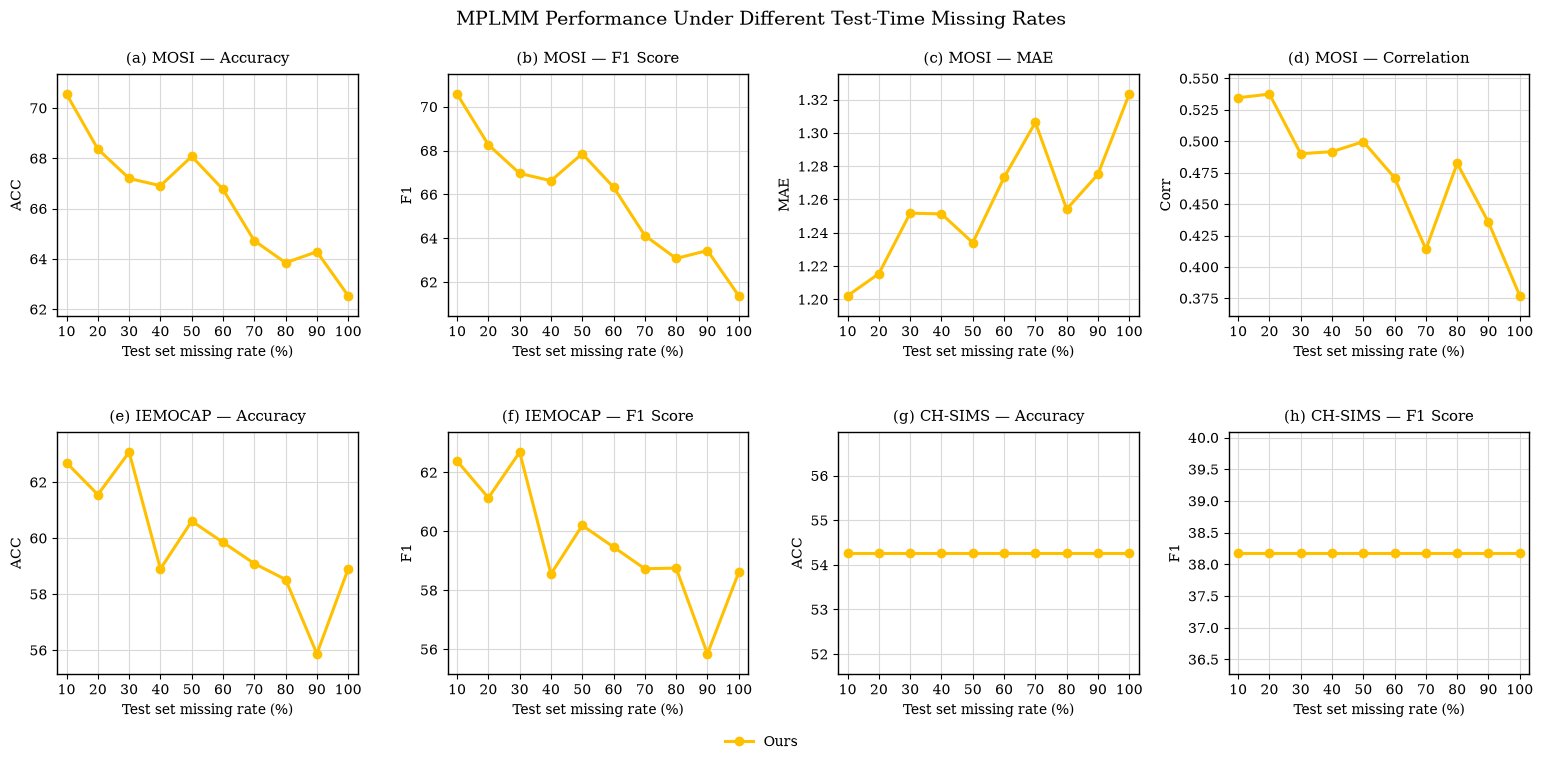

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


OURS_COLOR = "#FFC000"
x = np.asarray(TEST_MISSING_RATES)


def get_values(curve, key):
    values = np.asarray(
        [row.get(key, np.nan) for row in curve],
        dtype=float,
    )

    if len(values) != len(x):
        raise ValueError(
            f"{key}: expected {len(x)} values, got {len(values)}"
        )

    if not np.isfinite(values).any():
        raise ValueError(
            f"{key}: no valid values found. "
            "Check whether the corresponding evaluation completed."
        )

    return values


def set_dynamic_ylim(ax, values, padding_ratio=0.10):
    finite_values = values[np.isfinite(values)]
    value_min = finite_values.min()
    value_max = finite_values.max()

    if np.isclose(value_min, value_max):
        padding = max(abs(value_min) * 0.05, 1.0)
    else:
        padding = (value_max - value_min) * padding_ratio

    ax.set_ylim(value_min - padding, value_max + padding)


def plot_metric(ax, curve, metric, title):
    values = get_values(curve, metric)

    ax.plot(
        x,
        values,
        color=OURS_COLOR,
        marker="o",
        markersize=6,
        linewidth=2.2,
        markerfacecolor=OURS_COLOR,
        markeredgecolor=OURS_COLOR,
    )

    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Test set missing rate (%)")
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xlim(7, 103)

    set_dynamic_ylim(ax, values)

    ax.grid(
        True,
        color="#D9D9D9",
        linewidth=0.8,
    )
    ax.set_axisbelow(True)


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
})


fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.13,
    top=0.88,
    wspace=0.30,
    hspace=0.48,
)


# Top row: MOSI
plot_metric(
    axes[0, 0],
    mosi_curve,
    "ACC",
    "(a) MOSI — Accuracy",
)

plot_metric(
    axes[0, 1],
    mosi_curve,
    "F1",
    "(b) MOSI — F1 Score",
)

plot_metric(
    axes[0, 2],
    mosi_curve,
    "MAE",
    "(c) MOSI — MAE",
)

plot_metric(
    axes[0, 3],
    mosi_curve,
    "Corr",
    "(d) MOSI — Correlation",
)


# Bottom row: IEMOCAP and CH-SIMS
plot_metric(
    axes[1, 0],
    iemocap_curve,
    "ACC",
    "(e) IEMOCAP — Accuracy",
)

plot_metric(
    axes[1, 1],
    iemocap_curve,
    "F1",
    "(f) IEMOCAP — F1 Score",
)

plot_metric(
    axes[1, 2],
    sims_curve,
    "ACC",
    "(g) CH-SIMS — Accuracy",
)

plot_metric(
    axes[1, 3],
    sims_curve,
    "F1",
    "(h) CH-SIMS — F1 Score",
)


legend_handle = Line2D(
    [0],
    [0],
    color=OURS_COLOR,
    marker="o",
    linewidth=2.2,
    markersize=6,
    label="Ours",
)

fig.legend(
    handles=[legend_handle],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    frameon=False,
)

fig.suptitle(
    "MPLMM Performance Under Different Test-Time Missing Rates",
    fontsize=14,
    y=0.96,
)

plt.show()

In [20]:
from pathlib import Path

# Save Figure 4 outputs
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

figure4_png = results_dir / "figure4_mplmm.png"
figure4_pdf = results_dir / "figure4_mplmm.pdf"

fig.savefig(figure4_png, dpi=300, bbox_inches="tight")
fig.savefig(figure4_pdf, bbox_inches="tight")

print(f"Saved Figure 4 PNG: {figure4_png.resolve()}")
print(f"Saved Figure 4 PDF: {figure4_pdf.resolve()}")

plt.show()

Saved Figure 4 PNG: /home/cse/Desktop/MLProjectVidit/MPLMM/results/figure4_mplmm.png
Saved Figure 4 PDF: /home/cse/Desktop/MLProjectVidit/MPLMM/results/figure4_mplmm.pdf


In [16]:
from collections import Counter
from types import SimpleNamespace
from torch.utils.data import DataLoader
from src.utils import get_data

def inspect_sims_modes(missing_rate):
    args = SimpleNamespace(
        dataset="sims",
        data_path="dataset/sims_data.pkl",
        drop_rate=missing_rate,
    )

    dataset = get_data(
        args,
        split="test",
        full_data=False,
    )

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
    )

    modes = []

    for _, _, batch_modes in loader:
        modes.extend(batch_modes.tolist())

    print(
        f"Missing rate {missing_rate:.0%}:",
        Counter(modes),
    )


for rate in [0.1, 0.5, 0.7, 1.0]:
    inspect_sims_modes(rate)

Missing rate 10%: Counter({6: 407, 5: 11, 2: 9, 1: 8, 0: 8, 3: 8, 4: 6})
Missing rate 50%: Counter({6: 236, 2: 47, 3: 38, 0: 36, 4: 34, 1: 34, 5: 32})
Missing rate 70%: Counter({6: 149, 5: 61, 3: 58, 1: 53, 2: 47, 0: 47, 4: 42})
Missing rate 100%: Counter({0: 85, 4: 83, 3: 77, 2: 75, 1: 73, 5: 64})


In [17]:
import os
import torch
from types import SimpleNamespace
from torch.utils.data import DataLoader
from src.utils import get_data

checkpoint_path = "results/sims_stage2_seed_1111_30ep.pt"
data_path = "dataset/sims_data.pkl"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)
model = model.to(device).eval()

args = SimpleNamespace(
    dataset="sims",
    data_path=data_path,
    drop_rate=0.0,
)

dataset = get_data(
    args,
    split="test",
    full_data=True,
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
)

batch_x, _, _ = next(iter(loader))
text, audio, vision = batch_x

text = text.to(device)
audio = audio.to(device)
vision = vision.to(device)

with torch.no_grad():
    outputs = {}

    for mode in range(7):
        modes = torch.full(
            (text.size(0),),
            mode,
            dtype=torch.long,
            device=device,
        )

        outputs[mode] = model(
            text,
            audio,
            vision,
            modes,
        ).detach().cpu()

for mode in range(1, 7):
    difference = (outputs[mode] - outputs[0]).abs().mean().item()
    print(f"Difference between mode 0 and mode {mode}: {difference:.8f}")

Difference between mode 0 and mode 1: 0.01501075
Difference between mode 0 and mode 2: 0.01883485
Difference between mode 0 and mode 3: 0.01640873
Difference between mode 0 and mode 4: 0.01597383
Difference between mode 0 and mode 5: 0.01482642
Difference between mode 0 and mode 6: 0.01617611


In [18]:
import numpy as np
import torch

# Reuse model, loader, device, text, audio, and vision from the previous
# diagnostic cell. If those variables no longer exist, rerun that cell first.

batch_x, batch_y, _ = next(iter(loader))
text, audio, vision = batch_x

text = text.to(device)
audio = audio.to(device)
vision = vision.to(device)

with torch.no_grad():
    outputs = {}

    for mode in range(7):
        modes = torch.full(
            (text.size(0),),
            mode,
            dtype=torch.long,
            device=device,
        )

        outputs[mode] = (
            model(text, audio, vision, modes)
            .detach()
            .cpu()
            .view(-1)
            .numpy()
        )

labels = batch_y.detach().cpu().view(-1).numpy()

print("Label statistics")
print("---------------")
print("min:", labels.min())
print("max:", labels.max())
print("mean:", labels.mean())
print("negative labels:", np.sum(labels < 0))
print("zero labels:", np.sum(labels == 0))
print("positive labels:", np.sum(labels > 0))

print("\nPrediction statistics")
print("--------------------")

for mode in range(7):
    predictions = outputs[mode]

    print(
        f"mode {mode}: "
        f"min={predictions.min():.4f}, "
        f"max={predictions.max():.4f}, "
        f"mean={predictions.mean():.4f}, "
        f"negative={np.sum(predictions < 0)}, "
        f"zero={np.sum(predictions == 0)}, "
        f"positive={np.sum(predictions >= 0)}"
    )

Label statistics
---------------
min: -1.0
max: 1.0
mean: -0.128125
negative labels: 34
zero labels: 7
positive labels: 23

Prediction statistics
--------------------
mode 0: min=-0.2377, max=-0.1839, mean=-0.2111, negative=64, zero=0, positive=0
mode 1: min=-0.2026, max=-0.1893, mean=-0.1979, negative=64, zero=0, positive=0
mode 2: min=-0.2038, max=-0.1844, mean=-0.1927, negative=64, zero=0, positive=0
mode 3: min=-0.2090, max=-0.1790, mean=-0.1951, negative=64, zero=0, positive=0
mode 4: min=-0.2029, max=-0.1910, mean=-0.1958, negative=64, zero=0, positive=0
mode 5: min=-0.2040, max=-0.1879, mean=-0.1975, negative=64, zero=0, positive=0
mode 6: min=-0.2025, max=-0.1917, mean=-0.1960, negative=64, zero=0, positive=0


In [26]:
import os
from collections import Counter
from types import SimpleNamespace

import numpy as np
import torch
from torch.utils.data import DataLoader

from src.utils import get_data


DATASETS = {
    "mosi": {
        "data_path": "dataset/mosi_data.pkl",
        "checkpoint": "results/mosi_stage2_seed_1111_30ep.pt",
    },
    "mosei": {
        "data_path": "dataset/mosei_senti_data.pkl",
        "checkpoint": "results/mosei_stage2_seed_1111_30ep.pt",
    },
    "iemocap": {
        "data_path": "dataset/iemocap/IEMOCAP_features_2021",
        "checkpoint": "results/iemocap_stage2_seed_1111_30ep.pt",
    },
    "sims": {
        "data_path": "dataset/sims_data.pkl",
        "checkpoint": "results/sims_stage2_seed_1111_30ep.pt",
    },
}


def prediction_statistics(dataset_name, data_path, checkpoint_path):
    if not os.path.exists(data_path):
        print(f"\n{dataset_name}: dataset missing: {data_path}")
        return

    if not os.path.exists(checkpoint_path):
        print(f"\n{dataset_name}: checkpoint missing: {checkpoint_path}")
        return

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
    model = model.to(device).eval()

    args = SimpleNamespace(
        dataset=dataset_name,
        data_path=data_path,
        drop_rate=0.0,
    )

    dataset = get_data(
        args,
        split="test",
        full_data=True,
    )

    loader_kwargs = {
        "batch_size": 64,
        "shuffle": False,
    }

    if dataset_name == "iemocap":
        loader_kwargs["collate_fn"] = dataset.collate_fn

    loader = DataLoader(dataset, **loader_kwargs)

    print(f"\n{'=' * 80}")
    print(f"{dataset_name.upper()}")
    print(f"Checkpoint: {checkpoint_path}")
    print(f"{'=' * 80}")

    for mode in range(7):
        outputs = []

        with torch.no_grad():
            for batch_x, _, _ in loader:
                text, audio, vision = batch_x

                text = text.to(device)
                audio = audio.to(device)
                vision = vision.to(device)

                missing_modes = torch.full(
                    (text.size(0),),
                    mode,
                    dtype=torch.long,
                    device=device,
                )

                prediction = model(
                    text,
                    audio,
                    vision,
                    missing_modes,
                )

                outputs.append(prediction.detach().cpu())

        outputs = torch.cat(outputs)

        if dataset_name == "iemocap":
            logits = outputs.view(-1, 4).numpy()
            predicted_classes = logits.argmax(axis=1)
            class_counts = Counter(predicted_classes.tolist())

            print(
                f"mode {mode}: "
                f"logit_min={logits.min():.4f}, "
                f"logit_max={logits.max():.4f}, "
                f"logit_mean={logits.mean():.4f}, "
                f"predicted_classes={dict(sorted(class_counts.items()))}"
            )

        else:
            predictions = outputs.view(-1).numpy()
            positive = predictions >= 0

            print(
                f"mode {mode}: "
                f"min={predictions.min():.4f}, "
                f"max={predictions.max():.4f}, "
                f"mean={predictions.mean():.4f}, "
                f"std={predictions.std():.4f}, "
                f"negative={(predictions < 0).sum()}, "
                f"zero={(predictions == 0).sum()}, "
                f"positive={positive.sum()}"
            )


for dataset_name, config in DATASETS.items():
    prediction_statistics(
        dataset_name=dataset_name,
        data_path=config["data_path"],
        checkpoint_path=config["checkpoint"],
    )


MOSI
Checkpoint: results/mosi_stage2_seed_1111_30ep.pt
mode 0: min=-0.2356, max=0.6658, mean=0.1937, std=0.1776, negative=103, zero=0, positive=583
mode 1: min=-1.5292, max=2.0658, mean=0.4308, std=1.1739, negative=308, zero=0, positive=378
mode 2: min=-1.4172, max=1.9607, mean=0.2453, std=1.1408, negative=343, zero=0, positive=343
mode 3: min=-0.1580, max=0.5411, mean=0.2356, std=0.0970, negative=10, zero=0, positive=676
mode 4: min=-0.2479, max=0.3360, mean=0.0625, std=0.1073, negative=167, zero=0, positive=519
mode 5: min=-1.3380, max=2.1370, mean=0.3923, std=1.1253, negative=323, zero=0, positive=363
mode 6: min=-1.6545, max=1.9435, mean=0.3985, std=1.1353, negative=316, zero=0, positive=370

MOSEI
Checkpoint: results/mosei_stage2_seed_1111_30ep.pt
mode 0: min=-0.0440, max=1.4989, mean=0.4274, std=0.3108, negative=22, zero=0, positive=4621
mode 1: min=-2.0822, max=2.2148, mean=0.2760, std=0.6713, negative=1288, zero=0, positive=3355
mode 2: min=-2.1361, max=1.9258, mean=0.2782, st

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

print("Full-dataset CH-SIMS results by mode")
print("-" * 70)

for mode in range(7):
    predictions, truths = collect_sims_predictions(
        model=model,
        data_path="dataset/sims_data.pkl",
        mode=mode,
    )

    predicted_labels = predictions >= 0
    true_labels = truths >= 0

    accuracy = accuracy_score(true_labels, predicted_labels) * 100
    f1 = f1_score(
        true_labels,
        predicted_labels,
        average="weighted",
        zero_division=0,
    ) * 100

    print(
        f"mode {mode}: "
        f"samples={len(predictions)}, "
        f"pred_min={predictions.min():.4f}, "
        f"pred_max={predictions.max():.4f}, "
        f"pred_mean={predictions.mean():.4f}, "
        f"positive_predictions={predicted_labels.sum()}, "
        f"positive_labels={true_labels.sum()}, "
        f"ACC={accuracy:.2f}, "
        f"F1={f1:.2f}"
    )

Full-dataset CH-SIMS results by mode
----------------------------------------------------------------------
mode 0: samples=457, pred_min=-0.2542, pred_max=-0.1836, pred_mean=-0.2122, positive_predictions=0, positive_labels=209, ACC=54.27, F1=38.18
mode 1: samples=457, pred_min=-0.2051, pred_max=-0.1887, pred_mean=-0.1973, positive_predictions=0, positive_labels=209, ACC=54.27, F1=38.18
mode 2: samples=457, pred_min=-0.2038, pred_max=-0.1731, pred_mean=-0.1920, positive_predictions=0, positive_labels=209, ACC=54.27, F1=38.18
mode 3: samples=457, pred_min=-0.2122, pred_max=-0.1742, pred_mean=-0.1954, positive_predictions=0, positive_labels=209, ACC=54.27, F1=38.18
mode 4: samples=457, pred_min=-0.2036, pred_max=-0.1835, pred_mean=-0.1957, positive_predictions=0, positive_labels=209, ACC=54.27, F1=38.18
mode 5: samples=457, pred_min=-0.2040, pred_max=-0.1842, pred_mean=-0.1970, positive_predictions=0, positive_labels=209, ACC=54.27, F1=38.18
mode 6: samples=457, pred_min=-0.2045, pred_ma

In [22]:
import pickle
import numpy as np
import torch

with open("dataset/sims_data.pkl", "rb") as file:
    sims = pickle.load(file)

for split in ["train", "valid", "test"]:
    labels = np.asarray(sims[split]["regression_labels"]).reshape(-1)

    print(
        split,
        "samples:", len(labels),
        "min:", labels.min(),
        "max:", labels.max(),
        "mean:", labels.mean(),
        "positive:", np.sum(labels >= 0),
        "negative:", np.sum(labels < 0),
    )

train samples: 1368 min: -1.0 max: 1.0 mean: -0.19283625730994153 positive: 626 negative: 742
valid samples: 456 min: -1.0 max: 1.0 mean: -0.1942982456140351 positive: 208 negative: 248
test samples: 457 min: -1.0 max: 1.0 mean: -0.1925601750547046 positive: 209 negative: 248


In [23]:
import numpy as np
import torch
from types import SimpleNamespace
from torch.utils.data import DataLoader
from src.utils import get_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load(
    "results/sims_stage2_seed_1111_30ep.pt",
    map_location=device,
    weights_only=False,
).to(device).eval()


def inspect_split(split):
    args = SimpleNamespace(
        dataset="sims",
        data_path="dataset/sims_data.pkl",
        drop_rate=0.0,
    )

    dataset = get_data(args, split=split, full_data=True)
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    predictions = []
    truths = []

    with torch.no_grad():
        for batch_x, batch_y, _ in loader:
            text, audio, vision = batch_x

            output = model(
                text.to(device),
                audio.to(device),
                vision.to(device),
                torch.full(
                    (text.size(0),),
                    6,
                    dtype=torch.long,
                    device=device,
                ),
            )

            predictions.append(output.detach().cpu().view(-1))
            truths.append(batch_y.detach().cpu().view(-1))

    predictions = torch.cat(predictions).numpy()
    truths = torch.cat(truths).numpy()

    print(
        f"{split}: "
        f"pred_min={predictions.min():.4f}, "
        f"pred_max={predictions.max():.4f}, "
        f"pred_mean={predictions.mean():.4f}, "
        f"positive_predictions={(predictions >= 0).sum()}, "
        f"positive_labels={(truths >= 0).sum()}, "
        f"MAE={np.mean(np.abs(predictions - truths)):.4f}"
    )


for split in ["train", "valid", "test"]:
    inspect_split(split)

train: pred_min=-0.2119, pred_max=-0.1661, pred_mean=-0.1958, positive_predictions=0, positive_labels=626, MAE=0.5886
valid: pred_min=-0.2100, pred_max=-0.1874, pred_mean=-0.1960, positive_predictions=0, positive_labels=208, MAE=0.5881
test: pred_min=-0.2045, pred_max=-0.1903, pred_mean=-0.1958, positive_predictions=0, positive_labels=209, MAE=0.5885


In [24]:
import os
import sys
import subprocess

os.makedirs("results", exist_ok=True)

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--dataset", "sims",
        "--data_path", "dataset/sims_data.pkl",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "5",
        "--seed", "1111",
        "--name", "results/sims_from_scratch_diagnostic.pt",
        "--log_interval", "1",
    ],
    check=True,
)

/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [39] is 39 which does not match the computed number of elements 400. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (400,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


Epoch  1 | Batch   1/ 22 | Time/Batch(ms) 2177.08 | Train Loss 1.5847
Epoch  1 | Batch   2/ 22 | Time/Batch(ms) 321.48 | Train Loss 1.3834
Epoch  1 | Batch   3/ 22 | Time/Batch(ms) 324.81 | Train Loss 0.7141
Epoch  1 | Batch   4/ 22 | Time/Batch(ms) 324.47 | Train Loss 1.1810
Epoch  1 | Batch   5/ 22 | Time/Batch(ms) 323.50 | Train Loss 1.1336
Epoch  1 | Batch   6/ 22 | Time/Batch(ms) 323.33 | Train Loss 1.0944
Epoch  1 | Batch   7/ 22 | Time/Batch(ms) 324.04 | Train Loss 0.8087
Epoch  1 | Batch   8/ 22 | Time/Batch(ms) 323.96 | Train Loss 0.6430
Epoch  1 | Batch   9/ 22 | Time/Batch(ms) 325.85 | Train Loss 0.7814
Epoch  1 | Batch  10/ 22 | Time/Batch(ms) 321.05 | Train Loss 0.9310
Epoch  1 | Batch  11/ 22 | Time/Batch(ms) 325.15 | Train Loss 1.0559
Epoch  1 | Batch  12/ 22 | Time/Batch(ms) 324.58 | Train Loss 0.9316
Epoch  1 | Batch  13/ 22 | Time/Batch(ms) 328.14 | Train Loss 0.7307
Epoch  1 | Batch  14/ 22 | Time/Batch(ms) 326.30 | Train Loss 0.6316
Epoch  1 | Batch  15/ 22 | Time/B

/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([24, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: Using a target size (torch.Size([9])) that is different to the input size (torch.Size([9, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


--------------------------------------------------
Epoch  1 | Time 10.6946 sec | Valid Loss 0.6602 | Test Loss 0.6606
--------------------------------------------------
Saved model at results/sims_from_scratch_diagnostic.pt
Epoch  2 | Batch   1/ 22 | Time/Batch(ms) 657.10 | Train Loss 0.6223
Epoch  2 | Batch   2/ 22 | Time/Batch(ms) 332.26 | Train Loss 0.7272
Epoch  2 | Batch   3/ 22 | Time/Batch(ms) 323.44 | Train Loss 0.7766
Epoch  2 | Batch   4/ 22 | Time/Batch(ms) 328.10 | Train Loss 0.5940
Epoch  2 | Batch   5/ 22 | Time/Batch(ms) 328.59 | Train Loss 0.7883
Epoch  2 | Batch   6/ 22 | Time/Batch(ms) 326.25 | Train Loss 0.5951
Epoch  2 | Batch   7/ 22 | Time/Batch(ms) 328.89 | Train Loss 0.5915
Epoch  2 | Batch   8/ 22 | Time/Batch(ms) 321.26 | Train Loss 0.6615
Epoch  2 | Batch   9/ 22 | Time/Batch(ms) 327.24 | Train Loss 0.6452
Epoch  2 | Batch  10/ 22 | Time/Batch(ms) 328.01 | Train Loss 0.6547
Epoch  2 | Batch  11/ 22 | Time/Batch(ms) 327.70 | Train Loss 0.5228
Epoch  2 | Batch 

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--dataset', 'sims', '--data_path', 'dataset/sims_data.pkl', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '5', '--seed', '1111', '--name', 'results/sims_from_scratch_diagnostic.pt', '--log_interval', '1'], returncode=0)

In [25]:
sims_diagnostic = evaluate_dataset(
    dataset_name="sims",
    data_path="dataset/sims_data.pkl",
    checkpoint_path="results/sims_from_scratch_diagnostic.pt",
)

print_results("CH-SIMS diagnostic", sims_diagnostic)

Evaluating sims {a,v} using mode 0...
Evaluating sims {v,t} using mode 1...
Evaluating sims {a,t} using mode 2...
Evaluating sims {v} using mode 3...
Evaluating sims {a} using mode 4...
Evaluating sims {t} using mode 5...

CH-SIMS diagnostic
----------------------------------------------------------------------
 {a,v} | ACC:  54.27 | F1:  38.18
 {v,t} | ACC:  54.27 | F1:  38.18
 {a,t} | ACC:  54.27 | F1:  38.18
   {v} | ACC:  54.27 | F1:  38.18
   {a} | ACC:  54.27 | F1:  38.18
   {t} | ACC:  54.27 | F1:  38.18
  Avg. | ACC:  54.27 | F1:  38.18


In [12]:
from pathlib import Path

Path("results/figure6").mkdir(parents=True, exist_ok=True)

print("Output directory:", Path("results/figure6").resolve())

Output directory: /home/cse/Desktop/MLProjectVidit/MPLMM/results/figure6


In [13]:
import subprocess
import sys
from pathlib import Path

TRAIN_MISSING_RATES = list(range(10, 101, 10))
SEED = 1111

RESULTS_DIR = Path("results/figure6")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def train_for_figure6(dataset_name, data_path):
    for percentage in TRAIN_MISSING_RATES:
        RESULTS_DIR.mkdir(parents=True, exist_ok=True)

        checkpoint = (
            RESULTS_DIR
            / f"{dataset_name}_train_missing_{percentage}_seed_{SEED}.pt"
        )

        print(
            f"\n{'=' * 70}\n"
            f"Training {dataset_name.upper()} with "
            f"{percentage}% missing rate\n"
            f"Checkpoint: {checkpoint}\n"
            f"{'=' * 70}"
        )

        subprocess.run(
            [
                sys.executable,
                "main.py",
                "--pretrained_model", "pretrained/mosei.pt",
                "--dataset", dataset_name,
                "--data_path", data_path,
                "--optim", "Adam",
                "--batch_size", "64",
                "--lr", "1e-3",
                "--drop_rate", str(percentage / 100.0),
                "--num_epochs", "30",
                "--seed", str(SEED),
                "--name", str(checkpoint),
                "--log_interval", "30",
            ],
            check=True,
        )

In [14]:
%pwd

'/home/cse/Desktop/MLProjectVidit/MPLMM'

In [10]:
%cd Desktop/MLProjectVidit/MPLMM/

/home/cse/Desktop/MLProjectVidit/MPLMM


In [15]:
train_for_figure6(
    dataset_name="mosi",
    data_path="dataset/mosi_data.pkl",
)

train_for_figure6(
    dataset_name="iemocap",
    data_path="dataset/iemocap/IEMOCAP_features_2021",
)

train_for_figure6(
    dataset_name="sims",
    data_path="dataset/sims_data.pkl",
)


Training MOSI with 10% missing rate
Checkpoint: results/figure6/mosi_train_missing_10_seed_1111.pt
Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


--------------------------------------------------
Epoch  1 | Time 3.2059 sec | Valid Loss 1.4185 | Test Loss 1.4689
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_10_seed_1111.pt
--------------------------------------------------
Epoch  2 | Time 2.9315 sec | Valid Loss 1.4133 | Test Loss 1.4912
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_10_seed_1111.pt
--------------------------------------------------
Epoch  3 | Time 2.9276 sec | Valid Loss 1.4082 | Test Loss 1.4873
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_10_seed_1111.pt
--------------------------------------------------
Epoch  4 | Time 2.9276 sec | Valid Loss 1.4041 | Test Loss 1.4893
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_10_seed_1111.pt
--------------------------------------------------
Epoch  5 | Ti

/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


--------------------------------------------------
Epoch  1 | Time 5.5942 sec | Valid Loss 1.4184 | Test Loss 1.4621
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_20_seed_1111.pt
--------------------------------------------------
Epoch  2 | Time 6.6929 sec | Valid Loss 1.4112 | Test Loss 1.4795
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_20_seed_1111.pt
--------------------------------------------------
Epoch  3 | Time 8.2807 sec | Valid Loss 1.4083 | Test Loss 1.4838
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_20_seed_1111.pt
--------------------------------------------------
Epoch  4 | Time 11.4258 sec | Valid Loss 1.3978 | Test Loss 1.4850
--------------------------------------------------
Saved model at results/figure6/mosi_train_missing_20_seed_1111.pt
--------------------------------------------------
Epoch  5 | T

...

Epoch  1 | Batch  30/ 70 | Time/Batch(ms) 1709.49 | Train Loss 1.3777
Epoch  1 | Batch  60/ 70 | Time/Batch(ms) 1848.58 | Train Loss 1.3629
--------------------------------------------------
Epoch  1 | Time 142.0095 sec | Valid Loss 1.3244 | Test Loss 1.3210
--------------------------------------------------
Saved model at results/figure6/iemocap_train_missing_10_seed_1111.pt
Epoch  2 | Batch  30/ 70 | Time/Batch(ms) 2326.47 | Train Loss 1.2937
Epoch  2 | Batch  60/ 70 | Time/Batch(ms) 2275.60 | Train Loss 1.2299
--------------------------------------------------
Epoch  2 | Time 174.0518 sec | Valid Loss 1.1069 | Test Loss 1.1279
--------------------------------------------------
Saved model at results/figure6/iemocap_train_missing_10_seed_1111.pt
Epoch  3 | Batch  30/ 70 | Time/Batch(ms) 2228.78 | Train Loss 1.2020
Epoch  3 | Batch  60/ 70 | Time/Batch(ms) 2167.05 | Train Loss 1.1098
--------------------------------------------------
Epoch  3 | Time 166.8184 sec | Valid Loss 1.0969 | 

/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [22] is 22 which does not match the computed number of elements 350. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (350,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [350] is 350 which does not match the computed number of elements 366. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (366,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Epoch  1 | Batch  30/ 70 | Time/Batch(ms) 2098.79 | Train Loss 1.3849
Epoch  1 | Batch  60/ 70 | Time/Batch(ms) 2112.36 | Train Loss 1.3782
--------------------------------------------------
Epoch  1 | Time 160.9190 sec | Valid Loss 1.3244 | Test Loss 1.3900
--------------------------------------------------
Saved model at results/figure6/iemocap_train_missing_20_seed_1111.pt
Epoch  2 | Batch  30/ 70 | Time/Batch(ms) 2205.14 | Train Loss 1.3425
Epoch  2 | Batch  60/ 70 | Time/Batch(ms) 2177.62 | Train Loss 1.2806
--------------------------------------------------
Epoch  2 | Time 166.5254 sec | Valid Loss 1.1753 | Test Loss 1.2300
--------------------------------------------------
Saved model at results/figure6/iemocap_train_missing_20_seed_1111.pt
Epoch  3 | Batch  30/ 70 | Time/Batch(ms) 2218.26 | Train Loss 1.2379
Epoch  3 | Batch  60/ 70 | Time/Batch(ms) 2101.91 | Train Loss 1.1784
--------------------------------------------------
Epoch  3 | Time 163.7244 sec | Valid Loss 1.0686 | 

Traceback (most recent call last):
  File "/home/cse/Desktop/MLProjectVidit/MPLMM/main.py", line 163, in <module>
    train.initiate(hyp_params, trainloder, validloder, testloder)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cse/Desktop/MLProjectVidit/MPLMM/src/train.py", line 35, in initiate
    return train_model(settings, hyp_params, train_loader, valid_loader, test_loader)
  File "/home/cse/Desktop/MLProjectVidit/MPLMM/src/train.py", line 138, in train_model
    train(model, optimizer, criterion)
    ~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cse/Desktop/MLProjectVidit/MPLMM/src/train.py", line 67, in train
    preds = net(text, audio, vision, missing_mod)
  File "/home/cse/miniconda3/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1783, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/cse/miniconda3/lib/python3.14/site-packages/torch/nn/modules/module.

KeyboardInterrupt: 

Evaluating MOSI checkpoint at 10% training missing rate


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Evaluating MOSI checkpoint at 20% training missing rate
Evaluating MOSI checkpoint at 30% training missing rate
Evaluating MOSI checkpoint at 40% training missing rate
Evaluating MOSI checkpoint at 50% training missing rate
Evaluating MOSI checkpoint at 60% training missing rate
Evaluating MOSI checkpoint at 70% training missing rate
Evaluating MOSI checkpoint at 80% training missing rate
Evaluating MOSI checkpoint at 90% training missing rate
Evaluating MOSI checkpoint at 100% training missing rate


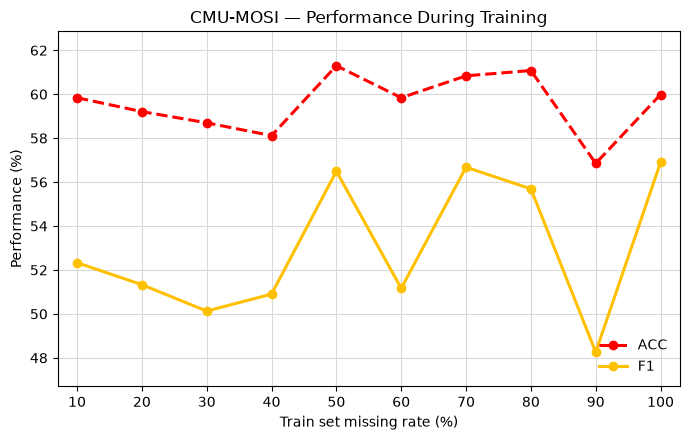

Saved:
results/figure6_mosi.png
results/figure6_mosi.pdf


In [19]:
import os
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

from src.utils import get_data


TRAIN_MISSING_RATES = list(range(10, 101, 10))

# Model modes:
# 0: text missing       -> {a,v}
# 1: audio missing      -> {v,t}
# 2: vision missing     -> {a,t}
# 3: text + audio       -> {v}
# 4: text + vision      -> {a}
# 5: audio + vision     -> {t}
CASE_MODES = {
    "{a,v}": 0,
    "{v,t}": 1,
    "{a,t}": 2,
    "{v}": 3,
    "{a}": 4,
    "{t}": 5,
}


def evaluate_mosi_checkpoint(checkpoint_path):
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    ).to(device).eval()

    args = SimpleNamespace(
        dataset="mosi",
        data_path="dataset/mosi_data.pkl",
        drop_rate=0.0,
    )

    dataset = get_data(
        args,
        split="test",
        full_data=True,
    )

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
    )

    results = {}

    for case_name, mode in CASE_MODES.items():
        predictions = []
        truths = []

        with torch.no_grad():
            for batch_x, batch_y, _ in loader:
                text, audio, vision = batch_x

                text = text.to(device)
                audio = audio.to(device)
                vision = vision.to(device)

                missing_modes = torch.full(
                    (text.size(0),),
                    mode,
                    dtype=torch.long,
                    device=device,
                )

                output = model(
                    text,
                    audio,
                    vision,
                    missing_modes,
                )

                predictions.append(output.detach().cpu().view(-1))
                truths.append(batch_y.detach().cpu().view(-1))

        predictions = torch.cat(predictions).numpy()
        truths = torch.cat(truths).numpy()

        # Exact requested conversion:
        # >= 0 -> positive, < 0 -> negative
        predicted_labels = predictions >= 0
        true_labels = truths >= 0

        results[case_name] = {
            "ACC": accuracy_score(
                true_labels,
                predicted_labels,
            ) * 100,
            "F1": f1_score(
                true_labels,
                predicted_labels,
                average="weighted",
                zero_division=0,
            ) * 100,
        }

    results["Avg."] = {
        "ACC": np.mean([
            results[case]["ACC"]
            for case in CASE_MODES
        ]),
        "F1": np.mean([
            results[case]["F1"]
            for case in CASE_MODES
        ]),
    }

    return results


# Check that all ten checkpoints exist.
checkpoint_paths = {
    rate: Path(
        f"results/figure6/"
        f"mosi_train_missing_{rate}_seed_1111.pt"
    )
    for rate in TRAIN_MISSING_RATES
}

missing = [
    f"{rate}%"
    for rate, path in checkpoint_paths.items()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing MOSI Figure 6 checkpoints: "
        + ", ".join(missing)
    )


# Evaluate all ten checkpoints.
acc_values = []
f1_values = []

for rate in TRAIN_MISSING_RATES:
    checkpoint = checkpoint_paths[rate]

    print(f"Evaluating MOSI checkpoint at {rate}% training missing rate")

    results = evaluate_mosi_checkpoint(checkpoint)

    acc_values.append(results["Avg."]["ACC"])
    f1_values.append(results["Avg."]["F1"])


# Plot Figure 6.
x = np.asarray(TRAIN_MISSING_RATES)
acc_values = np.asarray(acc_values)
f1_values = np.asarray(f1_values)

ACC_COLOR = "#FF0000"
F1_COLOR = "#FFC000"

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    x,
    acc_values,
    color=ACC_COLOR,
    linestyle="--",
    marker="o",
    linewidth=2.2,
    markersize=6,
    label="ACC",
)

ax.plot(
    x,
    f1_values,
    color=F1_COLOR,
    linestyle="-",
    marker="o",
    linewidth=2.2,
    markersize=6,
    label="F1",
)

all_values = np.concatenate([acc_values, f1_values])
padding = max(
    (all_values.max() - all_values.min()) * 0.12,
    1.0,
)

ax.set_xlim(7, 103)
ax.set_ylim(
    all_values.min() - padding,
    all_values.max() + padding,
)
ax.set_xticks(x)
ax.set_xlabel("Train set missing rate (%)")
ax.set_ylabel("Performance (%)")
ax.set_title("CMU-MOSI — Performance During Training")

ax.grid(
    True,
    color="#D9D9D9",
    linewidth=0.8,
)
ax.set_axisbelow(True)

ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=ACC_COLOR,
            linestyle="--",
            marker="o",
            linewidth=2.2,
            markersize=6,
            label="ACC",
        ),
        Line2D(
            [0],
            [0],
            color=F1_COLOR,
            linestyle="-",
            marker="o",
            linewidth=2.2,
            markersize=6,
            label="F1",
        ),
    ],
    loc="lower right",
    frameon=False,
)

fig.tight_layout()

Path("results").mkdir(exist_ok=True)

fig.savefig(
    "results/figure6_mosi.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "results/figure6_mosi.pdf",
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print("results/figure6_mosi.png")
print("results/figure6_mosi.pdf")

# CH-SIMS reproduction (fixed pipeline)

The earlier CH-SIMS runs **collapsed to a constant prediction** (≈ −0.196 for every sample, ACC 54.27 = share of negative labels, identical across all missing-modality cases). Two root causes:

1. **Label shape bug.** SIMS `regression_labels` are `(N,)`, so the batch labels were `[B]` while predictions were `[B, 1]`. `L1Loss` broadcast this to a `[B, B]` matrix, whose minimiser is a constant (the label median).
   *Fix:* `SIMSData` now returns labels shaped `(1, 1)` like MOSI/MOSEI, and `train.py` asserts `preds.shape == labels.shape`.
2. **Unnormalised features.** Raw SIMS vision has std ≈ 1.3e5 (max ≈ 2.8e7), audio std ≈ 40.
   *Fix:* audio/vision are z-scored per feature using **train-split** statistics, then clipped to ±10 (`--sims_norm 1`, default).

Also fixed: `train.py` now reports final metrics on the **test** split, and `f1_score` arguments in `eval_metrics.py` are in `(y_true, y_pred)` order.

**Metric convention:** positive iff label/prediction `> 0` (as in `eval_sims`). 69 of 457 test labels are exactly 0; the earlier evaluator used `>= 0`, which counts them as positive. Numbers in this section are therefore not directly comparable to the earlier CH-SIMS table.

**Steps in this section**

| Step | What | Why |
|---|---|---|
| 0 | Setup + reload patched modules | the kernel may still hold the old `SIMSData` |
| 1 | Data sanity check | label/batch shapes, feature scales after normalisation |
| 3 | Stage 2, paper setting (MOSEI-pretrained, drop 0.7, 30 ep) | the actual reproduction run + collapse check |
| 4 | LR sweep {1e-3, 5e-4, 1e-4}, selected on **valid** | SIMS is small (1,368 train); 1e-3 may be too high |
| 5 | Multi-seed runs with the selected LR, mean ± std on **test** | single-seed results on 457 samples are noisy |
| 6 | (Optional) ablation: `--sims_norm 0` | quantifies what normalisation contributes |

In [2]:
# Step 0: setup. Run this first after restarting the kernel.
import importlib
import os
import subprocess
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

# Make sure we are inside MPLMM/ regardless of where earlier cells left us.
if Path("MPLMM").is_dir() and not Path("main.py").exists():
    os.chdir("MPLMM")
assert Path("main.py").exists(), f"Expected to be in MPLMM/, cwd is {Path.cwd()}"
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

# Pick up the patched SIMSData even if the old one is already imported.
import src.simsdata
import src.utils
importlib.reload(src.simsdata)
importlib.reload(src.utils)
from src.utils import get_data

SIMS_PATH = "dataset/sims_data.pkl"
SIMS_DIR = Path("results/sims_fixed")
SIMS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Binary sentiment: positive iff > 0, as in src/eval_metrics.eval_sims (and the MMSA
# SIMS convention, bins (-1, 0] / (0, 1]). 69 of 457 test labels are exactly 0, so
# using >= 0 instead shifts ACC/F1 by several points.
def _binarize(x, zero_positive=False):
    return x >= 0 if zero_positive else x > 0

# Same convention as the paper table: column = AVAILABLE modalities.
SIMS_CASES = {"{a}": 4, "{v}": 3, "{t}": 5, "{a,v}": 0, "{a,t}": 2, "{v,t}": 1}


def train_sims(name, pretrained=True, lr=1e-3, drop_rate=0.7, epochs=30, seed=1111, sims_norm=1):
    """Train via main.py; skips if the checkpoint already exists."""
    ckpt = SIMS_DIR / name
    if ckpt.exists():
        print(f"[skip] {ckpt} already exists")
        return str(ckpt)
    cmd = [
        sys.executable, "main.py",
        "--dataset", "sims", "--data_path", SIMS_PATH,
        "--optim", "Adam", "--batch_size", "64",
        "--lr", str(lr), "--drop_rate", str(drop_rate),
        "--num_epochs", str(epochs), "--seed", str(seed),
        "--sims_norm", str(sims_norm),
        "--name", str(ckpt), "--log_interval", "100",
    ]
    if pretrained:
        cmd[2:2] = ["--pretrained_model", "pretrained/mosei.pt"]
    env = dict(os.environ, PYTHONWARNINGS="ignore")
    subprocess.run(cmd, check=True, env=env)
    return str(ckpt)


def _predict(model, loader, mode):
    preds, truths = [], []
    with torch.no_grad():
        for (text, audio, vision), y, _ in loader:
            modes = torch.full((text.size(0),), mode, dtype=torch.long, device=DEVICE)
            out = model(text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE), modes)
            preds.append(out.detach().cpu().view(-1))
            truths.append(y.detach().cpu().view(-1))
    return torch.cat(preds).numpy(), torch.cat(truths).numpy()


def eval_sims_checkpoint(ckpt, split="test", sims_norm=1, verbose=True, zero_positive=False):
    """Per-case ACC/F1 (positive iff > 0, or >= 0 with zero_positive=True) plus prediction stats."""
    model = torch.load(ckpt, map_location=DEVICE, weights_only=False).to(DEVICE).eval()
    args = SimpleNamespace(dataset="sims", data_path=SIMS_PATH, drop_rate=0.0, sims_norm=sims_norm)
    loader = DataLoader(get_data(args, split=split, full_data=True), batch_size=64, shuffle=False)

    res = {}
    for case, mode in list(SIMS_CASES.items()) + [("full", 6)]:
        p, t = _predict(model, loader, mode)
        res[case] = {
            "ACC": accuracy_score(_binarize(t, zero_positive), _binarize(p, zero_positive)) * 100,
            "F1": f1_score(_binarize(t, zero_positive), _binarize(p, zero_positive), average="weighted", zero_division=0) * 100,
            "MAE": float(np.mean(np.abs(p - t))),
            "Corr": float(np.corrcoef(p, t)[0, 1]) if p.std() > 0 else float("nan"),
            "pred_std": float(p.std()),
            "pos_pred": int(_binarize(p, zero_positive).sum()),
            "pos_true": int(_binarize(t, zero_positive).sum()),
        }
    res["Avg."] = {k: float(np.mean([res[c][k] for c in SIMS_CASES])) for k in ["ACC", "F1"]}

    if verbose:
        df = pd.DataFrame(res).T[["ACC", "F1", "MAE", "Corr", "pred_std", "pos_pred", "pos_true"]]
        print(f"{ckpt}  [{split}]")
        display(df.round(3))
        collapsed = [c for c in SIMS_CASES if res[c]["pred_std"] < 0.05]
        if collapsed:
            print(f"WARNING: near-constant predictions (std < 0.05) in cases: {collapsed}")
    return res


def results_row(name, res):
    row = {"Run": name}
    for c in SIMS_CASES:
        row[f"{c} ACC"] = res[c]["ACC"]
        row[f"{c} F1"] = res[c]["F1"]
    row["Avg. ACC"], row["Avg. F1"] = res["Avg."]["ACC"], res["Avg."]["F1"]
    return row


print("cwd:", Path.cwd(), "| device:", DEVICE)

cwd: /home/cse/Desktop/MLProjectVidit/MPLMM | device: cuda


In [3]:
# Step 1: data sanity check
from collections import Counter

args = SimpleNamespace(dataset="sims", data_path=SIMS_PATH, drop_rate=0.7, sims_norm=1)
for split in ["train", "valid", "test"]:
    ds = get_data(args, split=split)
    print(f"{split:5s}: n={len(ds)}, dims(t,a,v)={ds.get_dim()}, seq_len(t,a,v)={ds.get_seq_len()}")

ds = get_data(args, split="train")
for key in ["text", "audio", "vision"]:
    f = ds.feats[key]
    print(f"  train {key:6s}: mean={f.mean():8.3f}  std={f.std():8.3f}  absmax={np.abs(f).max():8.3f}")

(text, audio, vision), y, modes = next(iter(DataLoader(ds, batch_size=64, shuffle=False)))
print("batch shapes:", tuple(text.shape), tuple(audio.shape), tuple(vision.shape), "labels", tuple(y.shape))
assert y.shape[1:] == (1, 1), "labels must be (B, 1, 1) so that squeeze(-1) -> (B, 1) == preds"
print("label after squeeze(-1):", tuple(y.squeeze(-1).shape), "(must match model output (B, 1))")
print("missing-mode mix in one batch at drop 0.7:", dict(sorted(Counter(modes.tolist()).items())))

train: n=1368, dims(t,a,v)=[768, 33, 709], seq_len(t,a,v)=(39, 400, 55)
valid: n=456, dims(t,a,v)=[768, 33, 709], seq_len(t,a,v)=(39, 400, 55)
test : n=457, dims(t,a,v)=[768, 33, 709], seq_len(t,a,v)=(39, 400, 55)
  train text  : mean=  -0.003  std=   0.763  absmax=  17.476
  train audio : mean=  -0.000  std=   1.000  absmax=  10.000
  train vision: mean=  -0.000  std=   0.999  absmax=  10.000
batch shapes: (64, 39, 768) (64, 400, 33) (64, 55, 709) labels (64, 1, 1)
label after squeeze(-1): (64, 1) (must match model output (B, 1))
missing-mode mix in one batch at drop 0.7: {0: 7, 1: 5, 2: 11, 3: 6, 4: 3, 5: 13, 6: 19}


In [5]:
# Step 3: stage 2, paper setting (MOSEI-pretrained, missing rate 0.7, 30 epochs, lr 1e-3)
stage2_ckpt = train_sims(f"stage2_lr{1e-3:g}_seed1111.pt", pretrained=True, lr=1e-3)
stage2_res = eval_sims_checkpoint(stage2_ckpt, split="test")

[skip] results/sims_fixed/stage2_lr0.001_seed1111.pt already exists


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [39] is 39 which does not match the computed number of elements 400. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (400,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [400] is 400 which does not match the computed number of elements 416. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (416,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


results/sims_fixed/stage2_lr0.001_seed1111.pt  [test]


,ACC,F1,MAE,Corr,pred_std,pos_pred,pos_true
{a},67.396,60.681,0.588,0.101,0.222,41.0,140.0
{v},71.772,63.008,0.580,0.189,0.120,17.0,140.0
{t},78.556,78.374,0.448,0.549,0.522,132.0,140.0
"{a,v}",70.022,61.312,0.561,0.270,0.155,21.0,140.0
"{a,t}",79.650,79.629,0.437,0.559,0.510,139.0,140.0
"{v,t}",80.088,79.850,0.440,0.576,0.513,129.0,140.0
full,80.744,80.445,0.436,0.584,0.503,126.0,140.0
Avg.,74.581,70.476,NaN,NaN,NaN,NaN,NaN


## Step 3b: updated main table and Figure 4 (fixed CH-SIMS checkpoint)

Uses the Step 3 checkpoint. MOSI / IEMOCAP / MOSEI rows and curves are unchanged from the earlier evaluation (their evaluator counts `>= 0` as positive).
CH-SIMS uses `> 0` (zeros negative), the repo's `eval_sims` convention.

Requires the earlier evaluation cells (`evaluate_dataset`, `evaluate_figure4_dataset`) to have been run in this kernel; missing results are recomputed automatically.

In [ ]:
# Step 3b (i): updated main table
SIMS_CKPT = str(SIMS_DIR / f"stage2_lr{1e-3:g}_seed1111.pt")

_needed = {
    "mosi_results": ("mosi", "dataset/mosi_data.pkl", "results/mosi_stage2_seed_1111_30ep.pt"),
    "iemocap_results": ("iemocap", "dataset/iemocap/IEMOCAP_features_2021", "results/iemocap_stage2_seed_1111_30ep.pt"),
    "mosei_results": ("mosei", "dataset/mosei_senti_data.pkl", "results/mosei_stage2_seed_1111_30ep.pt"),
}
for var, (ds_name, ds_path, ckpt) in _needed.items():
    if var not in globals():
        assert "evaluate_dataset" in globals(), "Run the earlier evaluate_dataset definition cell first."
        globals()[var] = evaluate_dataset(dataset_name=ds_name, data_path=ds_path, checkpoint_path=ckpt)

sims_gt0 = eval_sims_checkpoint(SIMS_CKPT, split="test", verbose=False)


def table_row(dataset, res):
    row = {"Dataset": dataset}
    for c in SIMS_CASES:
        row[f"{c} ACC"], row[f"{c} F1"] = res[c]["ACC"], res[c]["F1"]
    row["Avg. ACC"], row["Avg. F1"] = res["Avg."]["ACC"], res["Avg."]["F1"]
    return row


updated_table = pd.DataFrame([
    table_row("MOSI", mosi_results),
    table_row("IEMOCAP", iemocap_results),
    table_row("CH-SIMS", sims_gt0),
    table_row("MOSEI", mosei_results),
])
display(updated_table.round(2))

updated_table.round(2).to_csv("results/table_main_sims_fixed.csv", index=False)
print("Saved: results/table_main_sims_fixed.csv")

In [ ]:
# Step 3b (ii): Figure 4 with the fixed CH-SIMS checkpoint
import random
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIG4_RATES = list(range(10, 101, 10))


def sims_missing_rate_curve(ckpt, rates=FIG4_RATES, seed=1111):
    """Test set with modes randomly dropped at each rate (same protocol as the earlier Figure 4)."""
    model = torch.load(ckpt, map_location=DEVICE, weights_only=False).to(DEVICE).eval()
    curve = []
    for pct in rates:
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        args = SimpleNamespace(dataset="sims", data_path=SIMS_PATH, drop_rate=pct / 100, sims_norm=1)
        loader = DataLoader(get_data(args, split="test", full_data=False), batch_size=64, shuffle=False)
        preds, truths = [], []
        with torch.no_grad():
            for (text, audio, vision), y, modes in loader:
                out = model(text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE), modes.to(DEVICE))
                preds.append(out.cpu().view(-1))
                truths.append(y.view(-1))
        p, t = torch.cat(preds).numpy(), torch.cat(truths).numpy()
        curve.append({
            "Missing rate": pct,
            "ACC": accuracy_score(_binarize(t), _binarize(p)) * 100,
            "F1": f1_score(_binarize(t), _binarize(p), average="weighted", zero_division=0) * 100,
            "MAE": float(np.mean(np.abs(p - t))),
            "Corr": float(np.corrcoef(p, t)[0, 1]),
        })
    return curve


sims_fixed_curve = sims_missing_rate_curve(SIMS_CKPT)
display(pd.DataFrame(sims_fixed_curve).set_index("Missing rate").round(3))

for var, (ds_name, ds_path, ckpt) in {
    "mosi_curve": ("mosi", "dataset/mosi_data.pkl", "results/mosi_stage2_seed_1111_30ep.pt"),
    "iemocap_curve": ("iemocap", "dataset/iemocap/IEMOCAP_features_2021", "results/iemocap_stage2_seed_1111_30ep.pt"),
}.items():
    if var not in globals():
        assert "evaluate_figure4_dataset" in globals(), "Run the earlier Figure 4 helper cell first."
        globals()[var] = evaluate_figure4_dataset(dataset_name=ds_name, data_path=ds_path, checkpoint_path=ckpt)

OURS_COLOR = "#FFC000"
plt.rcParams.update({"font.family": "serif", "font.size": 10})
fig4, axes = plt.subplots(2, 4, figsize=(16, 8))
fig4.subplots_adjust(left=0.06, right=0.98, bottom=0.13, top=0.88, wspace=0.30, hspace=0.48)

panels = [
    (axes[0, 0], mosi_curve, "ACC", "(a) MOSI — Accuracy"),
    (axes[0, 1], mosi_curve, "F1", "(b) MOSI — F1 Score"),
    (axes[0, 2], mosi_curve, "MAE", "(c) MOSI — MAE"),
    (axes[0, 3], mosi_curve, "Corr", "(d) MOSI — Correlation"),
    (axes[1, 0], iemocap_curve, "ACC", "(e) IEMOCAP — Accuracy"),
    (axes[1, 1], iemocap_curve, "F1", "(f) IEMOCAP — F1 Score"),
    (axes[1, 2], sims_fixed_curve, "ACC", "(g) CH-SIMS — Accuracy"),
    (axes[1, 3], sims_fixed_curve, "F1", "(h) CH-SIMS — F1 Score"),
]
x = np.asarray(FIG4_RATES)
for ax, curve, metric, title in panels:
    y = np.asarray([row[metric] for row in curve], dtype=float)
    ax.plot(x, y, color=OURS_COLOR, marker="o", markersize=6, linewidth=2.2)
    pad = max((y.max() - y.min()) * 0.10, 0.5 if metric in ("ACC", "F1") else 0.01)
    ax.set_ylim(y.min() - pad, y.max() + pad)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Test set missing rate (%)")
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xlim(7, 103)
    ax.grid(True, color="#D9D9D9", linewidth=0.8)
    ax.set_axisbelow(True)

fig4.legend(handles=[Line2D([0], [0], color=OURS_COLOR, marker="o", linewidth=2.2, label="Ours")],
            loc="lower center", bbox_to_anchor=(0.5, 0.02), frameon=False)
fig4.suptitle("MPLMM Performance Under Different Test-Time Missing Rates (CH-SIMS: fixed pipeline, > 0 threshold)",
              fontsize=13, y=0.96)

fig4.savefig("results/figure4_mplmm_sims_fixed.png", dpi=300, bbox_inches="tight")
fig4.savefig("results/figure4_mplmm_sims_fixed.pdf", bbox_inches="tight")
print("Saved: results/figure4_mplmm_sims_fixed.png / .pdf")
plt.show()

In [8]:
import pandas as pd

table = pd.read_csv("results/table_main_sims_fixed.csv")
pd.set_option("display.max_columns", None)
print(table.to_string(index=False))

Dataset  {a} ACC  {a} F1  {v} ACC  {v} F1  {t} ACC  {t} F1  {a,v} ACC  {a,v} F1  {a,t} ACC  {a,t} F1  {v,t} ACC  {v,t} F1  Avg. ACC  Avg. F1
   MOSI    55.10   52.15    45.34   29.67    71.72   71.77      50.73     44.26      72.89     72.96      69.24     69.25     60.84    56.68
IEMOCAP    49.43   45.39    54.55   52.77    50.95   51.89      61.93     59.86      61.93     61.59      62.31     62.01     56.85    55.59
CH-SIMS    67.40   60.68    71.77   63.01    78.56   78.37      70.02     61.31      79.65     79.63      80.09     79.85     74.58    70.48
  MOSEI    71.05   59.09    70.92   61.29    78.70   78.58      71.12     59.55      78.16     77.97      79.17     79.04     74.85    69.25


# IEMOCAP: improved training

Two fixes, both off by default in `main.py` (other datasets are unaffected):
- `--shuffle_train 1`: IEMOCAP files are ordered by session/dialogue, so without shuffling each batch is mostly one emotion from one conversation, in the same order every epoch.
- `--iemo_audio_len 150`: audio was zero-padded to 350 frames although utterances average ~45 (87% padding, no attention mask). 150 truncates only 1.2% of utterances.

Everything else is the paper setting (MOSEI-pretrained, missing rate 0.7, 30 epochs, lr 1e-3, seed 1111).

In [9]:
# IEMOCAP training (shuffle + audio length 150)
import os
import sys
import subprocess

os.makedirs("results", exist_ok=True)

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--pretrained_model", "pretrained/mosei.pt",
        "--dataset", "iemocap",
        "--data_path", "dataset/iemocap/IEMOCAP_features_2021",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "30",
        "--seed", "1111",
        "--shuffle_train", "1",
        "--iemo_audio_len", "150",
        "--name", "results/iemocap_stage2_shuffle_a150_seed_1111_30ep.pt",
        "--log_interval", "100",
    ],
    check=True,
)

Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [22] is 22 which does not match the computed number of elements 150. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (150,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [150] is 150 which does not match the computed number of elements 166. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (166,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


--------------------------------------------------
Epoch  1 | Time 27.3456 sec | Valid Loss 1.2321 | Test Loss 1.2295
--------------------------------------------------
Saved model at results/iemocap_stage2_shuffle_a150_seed_1111_30ep.pt
--------------------------------------------------
Epoch  2 | Time 16.3407 sec | Valid Loss 1.1927 | Test Loss 1.1988
--------------------------------------------------
Saved model at results/iemocap_stage2_shuffle_a150_seed_1111_30ep.pt
--------------------------------------------------
Epoch  3 | Time 24.6704 sec | Valid Loss 1.1820 | Test Loss 1.1635
--------------------------------------------------
Saved model at results/iemocap_stage2_shuffle_a150_seed_1111_30ep.pt
--------------------------------------------------
Epoch  4 | Time 60.7763 sec | Valid Loss 1.1276 | Test Loss 1.1567
--------------------------------------------------
Saved model at results/iemocap_stage2_shuffle_a150_seed_1111_30ep.pt
------------------------------------------------

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--pretrained_model', 'pretrained/mosei.pt', '--dataset', 'iemocap', '--data_path', 'dataset/iemocap/IEMOCAP_features_2021', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '30', '--seed', '1111', '--shuffle_train', '1', '--iemo_audio_len', '150', '--name', 'results/iemocap_stage2_shuffle_a150_seed_1111_30ep.pt', '--log_interval', '100'], returncode=0)

In [10]:
# IEMOCAP evaluation: compare with the original checkpoint on VALID, report TEST, update the table
import importlib
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

import src.iemodata
import src.utils
importlib.reload(src.iemodata)
importlib.reload(src.utils)
from src.utils import get_data

CASES = {"{a}": 4, "{v}": 3, "{t}": 5, "{a,v}": 0, "{a,t}": 2, "{v,t}": 1}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def eval_iemocap(checkpoint, split, audio_len):
    model = torch.load(checkpoint, map_location=device, weights_only=False).to(device).eval()
    args = SimpleNamespace(dataset="iemocap", data_path="dataset/iemocap/IEMOCAP_features_2021",
                           drop_rate=0.0, iemo_audio_len=audio_len)
    dataset = get_data(args, split=split, full_data=True)
    loader = DataLoader(dataset, batch_size=64, shuffle=False, collate_fn=dataset.collate_fn)
    row = {}
    for case, mode in CASES.items():
        preds, truths = [], []
        with torch.no_grad():
            for (text, audio, vision), y, _ in loader:
                modes = torch.full((text.size(0),), mode, dtype=torch.long, device=device)
                out = model(text.to(device), audio.to(device), vision.to(device), modes)
                preds.append(out.cpu().view(-1, 4).argmax(1))
                truths.append(y.view(-1).long().cpu())
        p, t = torch.cat(preds).numpy(), torch.cat(truths).numpy()
        row[f"{case} ACC"] = accuracy_score(t, p) * 100
        row[f"{case} F1"] = f1_score(t, p, average="weighted") * 100
    row["Avg. ACC"] = np.mean([row[f"{c} ACC"] for c in CASES])
    row["Avg. F1"] = np.mean([row[f"{c} F1"] for c in CASES])
    return row


old_ckpt, new_ckpt = "results/iemocap_stage2_seed_1111_30ep.pt", "results/iemocap_stage2_shuffle_a150_seed_1111_30ep.pt"
old_valid = eval_iemocap(old_ckpt, "valid", 350)
new_valid = eval_iemocap(new_ckpt, "valid", 150)
print(f"VALID Avg ACC/F1  original: {old_valid['Avg. ACC']:.2f}/{old_valid['Avg. F1']:.2f}"
      f"   new: {new_valid['Avg. ACC']:.2f}/{new_valid['Avg. F1']:.2f}")

table = pd.read_csv("results/table_main_sims_fixed.csv")
if new_valid["Avg. ACC"] > old_valid["Avg. ACC"]:
    new_test = eval_iemocap(new_ckpt, "test", 150)
    table.loc[table["Dataset"] == "IEMOCAP", list(new_test)] = [round(v, 2) for v in new_test.values()]
    table.to_csv("results/table_main_sims_fixed.csv", index=False)
    print("New IEMOCAP model is better on validation -> table updated with its TEST results.")
else:
    print("New IEMOCAP model is NOT better on validation -> table left unchanged.")

pd.set_option("display.max_columns", None)
print(table.to_string(index=False))

VALID Avg ACC/F1  original: 58.41/57.37   new: 61.55/60.40
New IEMOCAP model is better on validation -> table updated with its TEST results.
Dataset  {a} ACC  {a} F1  {v} ACC  {v} F1  {t} ACC  {t} F1  {a,v} ACC  {a,v} F1  {a,t} ACC  {a,t} F1  {v,t} ACC  {v,t} F1  Avg. ACC  Avg. F1
   MOSI    55.10   52.15    45.34   29.67    71.72   71.77      50.73     44.26      72.89     72.96      69.24     69.25     60.84    56.68
IEMOCAP    49.24   45.19    44.89   37.99    57.20   57.44      62.12     58.83      62.31     61.35      61.36     60.90     56.19    53.62
CH-SIMS    67.40   60.68    71.77   63.01    78.56   78.37      70.02     61.31      79.65     79.63      80.09     79.85     74.58    70.48
  MOSEI    71.05   59.09    70.92   61.29    78.70   78.58      71.12     59.55      78.16     77.97      79.17     79.04     74.85    69.25


# MOSI: improved training

Diagnosis of the original MOSI run:
- **Under-trained:** valid loss was still falling at epoch 30 (1.42 → 1.16). MOSI has only 20 batches/epoch, so 30 epochs is just 600 updates; the LR scheduler never decayed and test MAE was 1.17.
- **No shuffling:** `mosi_data.pkl` is ordered by video, so batches are made of consecutive clips from the same speaker, in the same order every epoch.

Two candidate runs (everything else is the paper setting: MOSEI-pretrained, missing rate 0.7, lr 1e-3, seed 1111):
- `shuffle_30ep`: `--shuffle_train 1`, 30 epochs (isolates the effect of shuffling)
- `shuffle_100ep`: `--shuffle_train 1`, 100 epochs (gives the model time to converge)

The best of {original, shuffle_30ep, shuffle_100ep} is chosen on the **validation** split; only that model's **test** results go into the table. The metric is unchanged (`>= 0`, same as the existing MOSI row).

In [11]:
# MOSI training (two candidates)
import os
import sys
import subprocess

os.makedirs("results", exist_ok=True)

MOSI_RUNS = {
    "shuffle_30ep": 30,
    "shuffle_100ep": 100,
}

for run_name, epochs in MOSI_RUNS.items():
    subprocess.run(
        [
            sys.executable,
            "main.py",
            "--pretrained_model", "pretrained/mosei.pt",
            "--dataset", "mosi",
            "--data_path", "dataset/mosi_data.pkl",
            "--optim", "Adam",
            "--batch_size", "64",
            "--lr", "1e-3",
            "--drop_rate", "0.7",
            "--num_epochs", str(epochs),
            "--seed", "1111",
            "--shuffle_train", "1",
            "--name", f"results/mosi_stage2_{run_name}_seed_1111.pt",
            "--log_interval", "100",
        ],
        check=True,
    )

Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


--------------------------------------------------
Epoch  1 | Time 14.9962 sec | Valid Loss 1.4159 | Test Loss 1.4646
--------------------------------------------------
Saved model at results/mosi_stage2_shuffle_30ep_seed_1111.pt
--------------------------------------------------
Epoch  2 | Time 14.7586 sec | Valid Loss 1.4145 | Test Loss 1.4922
--------------------------------------------------
Saved model at results/mosi_stage2_shuffle_30ep_seed_1111.pt
--------------------------------------------------
Epoch  3 | Time 14.7566 sec | Valid Loss 1.4163 | Test Loss 1.4725
--------------------------------------------------
--------------------------------------------------
Epoch  4 | Time 14.7424 sec | Valid Loss 1.4066 | Test Loss 1.4851
--------------------------------------------------
Saved model at results/mosi_stage2_shuffle_30ep_seed_1111.pt
--------------------------------------------------
Epoch  5 | Time 14.7273 sec | Valid Loss 1.4047 | Test Loss 1.4737
-----------------------

/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


--------------------------------------------------
Epoch  1 | Time 15.1849 sec | Valid Loss 1.4159 | Test Loss 1.4646
--------------------------------------------------
Saved model at results/mosi_stage2_shuffle_100ep_seed_1111.pt
--------------------------------------------------
Epoch  2 | Time 14.9607 sec | Valid Loss 1.4145 | Test Loss 1.4922
--------------------------------------------------
Saved model at results/mosi_stage2_shuffle_100ep_seed_1111.pt
--------------------------------------------------
Epoch  3 | Time 14.9554 sec | Valid Loss 1.4163 | Test Loss 1.4725
--------------------------------------------------
--------------------------------------------------
Epoch  4 | Time 14.9454 sec | Valid Loss 1.4066 | Test Loss 1.4851
--------------------------------------------------
Saved model at results/mosi_stage2_shuffle_100ep_seed_1111.pt
--------------------------------------------------
Epoch  5 | Time 14.9275 sec | Valid Loss 1.4047 | Test Loss 1.4737
--------------------

In [12]:
# MOSI evaluation: select on VALID, report TEST, update the table
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

from src.utils import get_data

CASES = {"{a}": 4, "{v}": 3, "{t}": 5, "{a,v}": 0, "{a,t}": 2, "{v,t}": 1}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def eval_mosi(checkpoint, split):
    model = torch.load(checkpoint, map_location=device, weights_only=False).to(device).eval()
    args = SimpleNamespace(dataset="mosi", data_path="dataset/mosi_data.pkl", drop_rate=0.0)
    loader = DataLoader(get_data(args, split=split, full_data=True), batch_size=64, shuffle=False)
    row = {}
    for case, mode in CASES.items():
        preds, truths = [], []
        with torch.no_grad():
            for (text, audio, vision), y, _ in loader:
                modes = torch.full((text.size(0),), mode, dtype=torch.long, device=device)
                out = model(text.to(device), audio.to(device), vision.to(device), modes)
                preds.append(out.cpu().view(-1))
                truths.append(y.cpu().view(-1))
        p, t = torch.cat(preds).numpy() >= 0, torch.cat(truths).numpy() >= 0
        row[f"{case} ACC"] = accuracy_score(t, p) * 100
        row[f"{case} F1"] = f1_score(t, p, average="weighted", zero_division=0) * 100
    row["Avg. ACC"] = np.mean([row[f"{c} ACC"] for c in CASES])
    row["Avg. F1"] = np.mean([row[f"{c} F1"] for c in CASES])
    return row


candidates = {
    "original": "results/mosi_stage2_seed_1111_30ep.pt",
    "shuffle_30ep": "results/mosi_stage2_shuffle_30ep_seed_1111.pt",
    "shuffle_100ep": "results/mosi_stage2_shuffle_100ep_seed_1111.pt",
}
valid = {name: eval_mosi(ckpt, "valid") for name, ckpt in candidates.items()}
for name, row in valid.items():
    print(f"VALID {name:14s} Avg ACC/F1: {row['Avg. ACC']:.2f} / {row['Avg. F1']:.2f}")

best = max(valid, key=lambda name: valid[name]["Avg. ACC"])
print("Selected on validation:", best)

table = pd.read_csv("results/table_main_sims_fixed.csv")
if best != "original":
    test_row = eval_mosi(candidates[best], "test")
    table.loc[table["Dataset"] == "MOSI", list(test_row)] = [round(v, 2) for v in test_row.values()]
    table.to_csv("results/table_main_sims_fixed.csv", index=False)
    print("Table updated with the TEST results of", best)
else:
    print("Original is still best on validation -> table left unchanged.")

pd.set_option("display.max_columns", None)
print(table.to_string(index=False))

VALID original       Avg ACC/F1: 66.30 / 62.46
VALID shuffle_30ep   Avg ACC/F1: 68.56 / 63.67
VALID shuffle_100ep  Avg ACC/F1: 66.16 / 64.29
Selected on validation: shuffle_30ep
Table updated with the TEST results of shuffle_30ep
Dataset  {a} ACC  {a} F1  {v} ACC  {v} F1  {t} ACC  {t} F1  {a,v} ACC  {a,v} F1  {a,t} ACC  {a,t} F1  {v,t} ACC  {v,t} F1  Avg. ACC  Avg. F1
   MOSI    47.23   36.99    48.69   40.30    75.07   75.08      50.87     45.63      75.95     75.90      75.51     75.49     62.22    58.23
IEMOCAP    49.24   45.19    44.89   37.99    57.20   57.44      62.12     58.83      62.31     61.35      61.36     60.90     56.19    53.62
CH-SIMS    67.40   60.68    71.77   63.01    78.56   78.37      70.02     61.31      79.65     79.63      80.09     79.85     74.58    70.48
  MOSEI    71.05   59.09    70.92   61.29    78.70   78.58      71.12     59.55      78.16     77.97      79.17     79.04     74.85    69.25


In [1]:
import sys
import subprocess
from pathlib import Path

Path("MPLMM/results").mkdir(parents=True, exist_ok=True)

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--pretrained_model", "pretrained/mosei.pt",
        "--dataset", "mosi",
        "--data_path", "dataset/mosi_data.pkl",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "30",
        "--seed", "1111",
        "--name", "results/mosi_stage2_seed_1111_30ep_avgf1.pt",
        "--log_interval", "10",
        "--shuffle_train",
        "--selection_metric", "avg_f1",
    ],
    cwd="MPLMM",
    check=True,
)

Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Epoch  1 | Batch  10/ 21 | Time/Batch(ms) 151.71 | Train Loss 1.3583
Epoch  1 | Batch  20/ 21 | Time/Batch(ms) 111.30 | Train Loss 1.2919
--------------------------------------------------
Epoch  1 | Time 5.0686 sec | Valid Loss 1.4159 | Test Loss 1.4646 | Avg Valid ACC 59.83 | Avg Valid F1 44.79
--------------------------------------------------
Saved model at results/mosi_stage2_seed_1111_30ep_avgf1.pt
Epoch  2 | Batch  10/ 21 | Time/Batch(ms) 129.80 | Train Loss 1.3158
Epoch  2 | Batch  20/ 21 | Time/Batch(ms) 110.26 | Train Loss 1.3238
--------------------------------------------------
Epoch  2 | Time 4.8468 sec | Valid Loss 1.4160 | Test Loss 1.4908 | Avg Valid ACC 59.83 | Avg Valid F1 44.79
--------------------------------------------------
Epoch  3 | Batch  10/ 21 | Time/Batch(ms) 129.21 | Train Loss 1.3113
Epoch  3 | Batch  20/ 21 | Time/Batch(ms) 116.03 | Train Loss 1.3219
--------------------------------------------------
Epoch  3 | Time 4.9664 sec | Valid Loss 1.4143 | Test 

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--pretrained_model', 'pretrained/mosei.pt', '--dataset', 'mosi', '--data_path', 'dataset/mosi_data.pkl', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '30', '--seed', '1111', '--name', 'results/mosi_stage2_seed_1111_30ep_avgf1.pt', '--log_interval', '10', '--shuffle_train', '--selection_metric', 'avg_f1'], returncode=0)

In [2]:
import sys
import subprocess
from pathlib import Path

Path("MPLMM/results").mkdir(parents=True, exist_ok=True)

subprocess.run(
    [
        sys.executable,
        "main.py",
        "--pretrained_model", "pretrained/mosei.pt",
        "--dataset", "iemocap",
        "--data_path", "dataset/iemocap/IEMOCAP_features_2021",
        "--optim", "Adam",
        "--batch_size", "64",
        "--lr", "1e-3",
        "--drop_rate", "0.7",
        "--num_epochs", "30",
        "--seed", "1111",
        "--name", "results/iemocap_stage2_seed_1111_30ep_avgf1.pt",
        "--log_interval", "10",
        "--shuffle_train",
        "--selection_metric", "avg_f1",
    ],
    cwd="MPLMM",
    check=True,
)

Missing key(s) in state_dict :proj_l.weight
Missing key(s) in state_dict :proj_a.weight
Missing key(s) in state_dict :proj_v.weight
Missing key(s) in state_dict :out_layer.weight
Missing key(s) in state_dict :out_layer.bias


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [22] is 22 which does not match the computed number of elements 350. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (350,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [350] is 350 which does not match the computed number of elements 366. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (366,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)


Epoch  1 | Batch  10/ 70 | Time/Batch(ms) 433.14 | Train Loss 1.3892
Epoch  1 | Batch  20/ 70 | Time/Batch(ms) 317.95 | Train Loss 1.3777
Epoch  1 | Batch  30/ 70 | Time/Batch(ms) 322.22 | Train Loss 1.3363
Epoch  1 | Batch  40/ 70 | Time/Batch(ms) 327.07 | Train Loss 1.3230
Epoch  1 | Batch  50/ 70 | Time/Batch(ms) 329.50 | Train Loss 1.3269
Epoch  1 | Batch  60/ 70 | Time/Batch(ms) 333.78 | Train Loss 1.2523
--------------------------------------------------
Epoch  1 | Time 36.5246 sec | Valid Loss 1.2277 | Test Loss 1.2201 | Avg Valid ACC 47.67 | Avg Valid F1 37.93
--------------------------------------------------
Saved model at results/iemocap_stage2_seed_1111_30ep_avgf1.pt
Epoch  2 | Batch  10/ 70 | Time/Batch(ms) 422.49 | Train Loss 1.2317
Epoch  2 | Batch  20/ 70 | Time/Batch(ms) 434.10 | Train Loss 1.2574
Epoch  2 | Batch  30/ 70 | Time/Batch(ms) 544.79 | Train Loss 1.1997
Epoch  2 | Batch  40/ 70 | Time/Batch(ms) 679.93 | Train Loss 1.1760
Epoch  2 | Batch  50/ 70 | Time/Batc

CompletedProcess(args=['/home/cse/miniconda3/bin/python', 'main.py', '--pretrained_model', 'pretrained/mosei.pt', '--dataset', 'iemocap', '--data_path', 'dataset/iemocap/IEMOCAP_features_2021', '--optim', 'Adam', '--batch_size', '64', '--lr', '1e-3', '--drop_rate', '0.7', '--num_epochs', '30', '--seed', '1111', '--name', 'results/iemocap_stage2_seed_1111_30ep_avgf1.pt', '--log_interval', '10', '--shuffle_train', '--selection_metric', 'avg_f1'], returncode=0)

In [5]:
%cd MPLMM

/home/cse/Desktop/MLProjectVidit/MPLMM


In [7]:
from pathlib import Path
from types import SimpleNamespace
import sys

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader


# Make `from src...` work from repo root or from inside MPLMM/
ROOT = Path.cwd()
MPLMM_ROOT = ROOT / "MPLMM" if (ROOT / "MPLMM").exists() else ROOT

if str(MPLMM_ROOT) not in sys.path:
    sys.path.insert(0, str(MPLMM_ROOT))

from src.utils import get_data


CASE_MODES = {
    "{a,v}": 0,
    "{v,t}": 1,
    "{a,t}": 2,
    "{v}": 3,
    "{a}": 4,
    "{t}": 5,
}


def build_test_loader(dataset_name, data_path, batch_size=64):
    args = SimpleNamespace(
        dataset=dataset_name,
        data_path=str(data_path),
        drop_rate=0.0,
    )

    dataset = get_data(
        args,
        split="test",
        full_data=True,
    )

    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": False,
    }

    if dataset_name == "iemocap":
        loader_kwargs["collate_fn"] = dataset.collate_fn

    return DataLoader(dataset, **loader_kwargs)


def evaluate_case(model, dataset_name, loader, mode):
    device = next(model.parameters()).device
    all_predictions = []
    all_truths = []

    model.eval()

    with torch.no_grad():
        for batch_x, batch_y, _ in loader:
            text, audio, vision = batch_x

            text = text.to(device)
            audio = audio.to(device)
            vision = vision.to(device)

            missing_modes = torch.full(
                (text.size(0),),
                mode,
                dtype=torch.long,
                device=device,
            )

            output = model(
                text,
                audio,
                vision,
                missing_modes,
            )

            all_predictions.append(output.detach().cpu())
            all_truths.append(batch_y.detach().cpu())

    predictions = torch.cat(all_predictions)
    truths = torch.cat(all_truths)

    if dataset_name == "iemocap":
        predicted_labels = predictions.view(-1, 4).argmax(dim=1).numpy()
        true_labels = truths.view(-1).long().numpy()

        accuracy = accuracy_score(true_labels, predicted_labels)
        f1 = f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        )
    else:
        predictions = predictions.view(-1).numpy()
        truths = truths.view(-1).numpy()

        predicted_labels = predictions >= 0
        true_labels = truths >= 0

        accuracy = accuracy_score(true_labels, predicted_labels)
        f1 = f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        )

    return {
        "ACC": float(accuracy * 100),
        "F1": float(f1 * 100),
    }


def evaluate_dataset(dataset_name, data_path, checkpoint_path, batch_size=64):
    data_path = Path(data_path)
    checkpoint_path = Path(checkpoint_path)

    if not data_path.exists():
        raise FileNotFoundError(f"Dataset not found: {data_path}")
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    ).to(device).eval()

    loader = build_test_loader(
        dataset_name,
        data_path,
        batch_size=batch_size,
    )

    results = {}

    for case_name, mode in CASE_MODES.items():
        results[case_name] = evaluate_case(
            model=model,
            dataset_name=dataset_name,
            loader=loader,
            mode=mode,
        )

    results["Avg."] = {
        "ACC": float(np.mean([results[case]["ACC"] for case in CASE_MODES])),
        "F1": float(np.mean([results[case]["F1"] for case in CASE_MODES])),
    }

    return results


def results_to_row(dataset_name, method_name, results):
    row = {
        "Dataset": dataset_name,
        "Method": method_name,
    }

    for case_name in CASE_MODES:
        row[f"{case_name} ACC"] = results[case_name]["ACC"]
        row[f"{case_name} F1"] = results[case_name]["F1"]

    row["Avg. ACC"] = results["Avg."]["ACC"]
    row["Avg. F1"] = results["Avg."]["F1"]
    return row


# Updated MOSI + updated IEMOCAP + base MOSEI
mosi_results = evaluate_dataset(
    dataset_name="mosi",
    data_path=MPLMM_ROOT / "dataset/mosi_data.pkl",
    checkpoint_path=MPLMM_ROOT / "results/mosi_stage2_seed_1111_30ep_avgf1.pt",
)

iemocap_results = evaluate_dataset(
    dataset_name="iemocap",
    data_path=MPLMM_ROOT / "dataset/iemocap/IEMOCAP_features_2021",
    checkpoint_path=MPLMM_ROOT / "results/iemocap_stage2_seed_1111_30ep_avgf1.pt",
)

mosei_results = evaluate_dataset(
    dataset_name="mosei",
    data_path=MPLMM_ROOT / "dataset/mosei_senti_data.pkl",
    checkpoint_path=MPLMM_ROOT / "results/mosei_stage2_seed_1111_30ep.pt",
)

# Fixed CH-SIMS row from the corrected table artifact
sims_fixed_csv = MPLMM_ROOT / "results/table_main_sims_fixed.csv"
if not sims_fixed_csv.exists():
    raise FileNotFoundError(f"Missing fixed CH-SIMS table: {sims_fixed_csv}")

sims_fixed_table = pd.read_csv(sims_fixed_csv)
sims_row = sims_fixed_table.loc[sims_fixed_table["Dataset"] == "CH-SIMS"].iloc[0].to_dict()
sims_row["Method"] = "Ours"

all_rows = [
    results_to_row("MOSI", "Ours", mosi_results),
    results_to_row("IEMOCAP", "Ours", iemocap_results),
    sims_row,
    results_to_row("MOSEI", "Ours", mosei_results),
]

table = pd.DataFrame(all_rows)

metric_columns = [
    "Dataset",
    "Method",
    "{a} ACC", "{a} F1",
    "{v} ACC", "{v} F1",
    "{t} ACC", "{t} F1",
    "{a,v} ACC", "{a,v} F1",
    "{a,t} ACC", "{a,t} F1",
    "{v,t} ACC", "{v,t} F1",
    "Avg. ACC", "Avg. F1",
]

final_table = table[metric_columns].round(2)
display(final_table)

,Dataset,Method,{a} ACC,{a} F1,{v} ACC,{v} F1,{t} ACC,{t} F1,"{a,v} ACC","{a,v} F1","{a,t} ACC","{a,t} F1","{v,t} ACC","{v,t} F1",Avg. ACC,Avg. F1
0,MOSI,Ours,47.81,38.67,49.71,44.12,76.38,76.17,54.66,53.59,76.53,76.34,76.09,75.89,63.53,60.80
1,IEMOCAP,Ours,51.89,49.16,52.46,50.42,54.92,53.31,64.20,61.74,63.26,60.73,62.12,60.72,58.14,56.01
2,CH-SIMS,Ours,67.40,60.68,71.77,63.01,78.56,78.37,70.02,61.31,79.65,79.63,80.09,79.85,74.58,70.48
3,MOSEI,Ours,71.05,59.09,70.92,61.29,78.70,78.58,71.12,59.55,78.16,77.97,79.17,79.04,74.85,69.25


/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [50] is 50 which does not match the computed number of elements 66. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (66,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The number of elements in the out tensor of shape [66] is 66 which does not match the computed number of elements 350. Note that this may occur as a result of rounding error. The out tensor will be resized to a tensor of shape (350,). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cuda/RangeFactories.cu:262.)
  return func(*args, **kwargs)
/home/cse/miniconda3/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: The n

Saved:
/home/cse/Desktop/MLProjectVidit/MPLMM/results/figure4_mplmm_sims_fixed.png
/home/cse/Desktop/MLProjectVidit/MPLMM/results/figure4_mplmm_sims_fixed.pdf


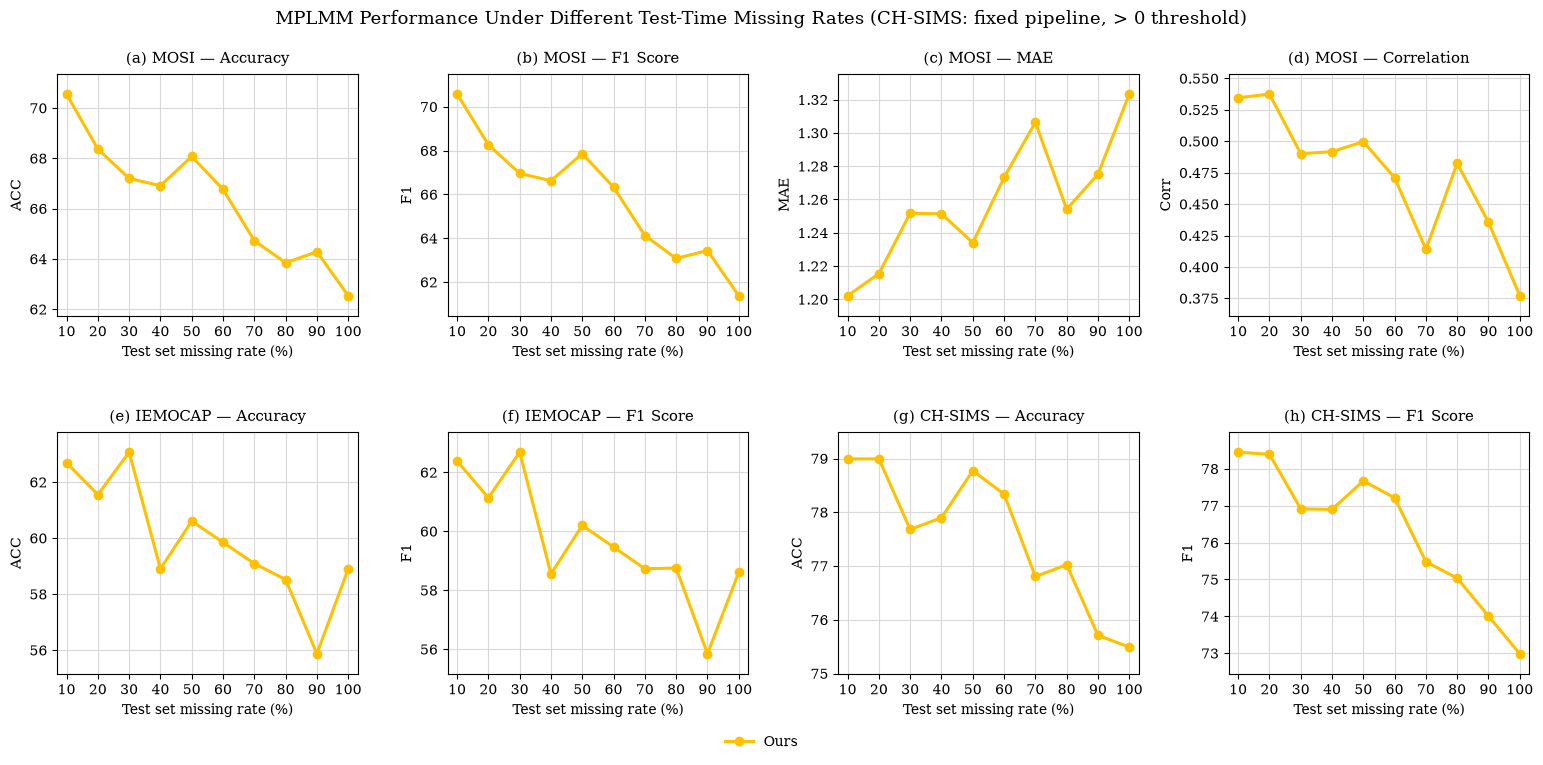

In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

# Make `from src...` work from repo root or from inside MPLMM/
ROOT = Path.cwd()
MPLMM_ROOT = ROOT / "MPLMM" if (ROOT / "MPLMM").exists() else ROOT

if str(MPLMM_ROOT) not in sys.path:
    sys.path.insert(0, str(MPLMM_ROOT))

from src.utils import get_data

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIG4_RATES = list(range(10, 101, 10))

# Use these to reproduce the exact style/behavior of the shown figure.
# If you want the improved MOSI/IEMOCAP curves instead, replace these with:
#   mosi_stage2_seed_1111_30ep_avgf1.pt
#   iemocap_stage2_seed_1111_30ep_avgf1.pt
MOSI_CKPT = MPLMM_ROOT / "results/mosi_stage2_seed_1111_30ep.pt"
IEMOCAP_CKPT = MPLMM_ROOT / "results/iemocap_stage2_seed_1111_30ep.pt"
SIMS_FIXED_CKPT = MPLMM_ROOT / "results/sims_fixed/stage2_lr0.001_seed1111.pt"

MOSI_PATH = MPLMM_ROOT / "dataset/mosi_data.pkl"
IEMOCAP_PATH = MPLMM_ROOT / "dataset/iemocap/IEMOCAP_features_2021"
SIMS_PATH = MPLMM_ROOT / "dataset/sims_data.pkl"

for path in [
    MOSI_CKPT, IEMOCAP_CKPT, SIMS_FIXED_CKPT,
    MOSI_PATH, IEMOCAP_PATH, SIMS_PATH,
]:
    if not Path(path).exists():
        raise FileNotFoundError(path)


def set_eval_seed(seed=1111):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_random_test_loader(dataset_name, data_path, missing_rate, batch_size=64):
    args = SimpleNamespace(
        dataset=dataset_name,
        data_path=str(data_path),
        drop_rate=missing_rate,
        sims_norm=1,
    )

    dataset = get_data(
        args,
        split="test",
        full_data=False,
    )

    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": False,
    }

    if dataset_name == "iemocap":
        loader_kwargs["collate_fn"] = dataset.collate_fn

    return DataLoader(dataset, **loader_kwargs)


def load_model(checkpoint_path):
    model = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
    return model.to(DEVICE).eval()


def binarize_ge0(values):
    return values >= 0


def binarize_gt0(values):
    return values > 0


def evaluate_missing_rate_curve(
    dataset_name,
    data_path,
    checkpoint_path,
    rates=FIG4_RATES,
    seed=1111,
    ch_sims_gt0=False,
):
    model = load_model(checkpoint_path)
    curve = []

    for pct in rates:
        set_eval_seed(seed)

        loader = build_random_test_loader(
            dataset_name=dataset_name,
            data_path=data_path,
            missing_rate=pct / 100.0,
            batch_size=64,
        )

        all_predictions = []
        all_truths = []

        with torch.no_grad():
            for batch_x, batch_y, missing_modes in loader:
                text, audio, vision = batch_x

                output = model(
                    text.to(DEVICE),
                    audio.to(DEVICE),
                    vision.to(DEVICE),
                    missing_modes.to(DEVICE),
                )

                all_predictions.append(output.detach().cpu())
                all_truths.append(batch_y.detach().cpu())

        predictions = torch.cat(all_predictions)
        truths = torch.cat(all_truths)

        if dataset_name == "iemocap":
            predicted_labels = predictions.view(-1, 4).argmax(dim=1).numpy()
            true_labels = truths.view(-1).long().numpy()

            curve.append({
                "Missing rate": pct,
                "ACC": accuracy_score(true_labels, predicted_labels) * 100,
                "F1": f1_score(
                    true_labels,
                    predicted_labels,
                    average="weighted",
                    zero_division=0,
                ) * 100,
            })
            continue

        predictions = predictions.view(-1).numpy()
        truths = truths.view(-1).numpy()

        binarize = binarize_gt0 if ch_sims_gt0 else binarize_ge0
        predicted_labels = binarize(predictions)
        true_labels = binarize(truths)

        row = {
            "Missing rate": pct,
            "ACC": accuracy_score(true_labels, predicted_labels) * 100,
            "F1": f1_score(
                true_labels,
                predicted_labels,
                average="weighted",
                zero_division=0,
            ) * 100,
        }

        if dataset_name == "mosi":
            row["MAE"] = float(np.mean(np.abs(predictions - truths)))
            row["Corr"] = (
                float(np.corrcoef(predictions, truths)[0, 1])
                if np.std(predictions) > 0 and np.std(truths) > 0
                else np.nan
            )

        curve.append(row)

    return curve


mosi_curve = evaluate_missing_rate_curve(
    dataset_name="mosi",
    data_path=MOSI_PATH,
    checkpoint_path=MOSI_CKPT,
)

iemocap_curve = evaluate_missing_rate_curve(
    dataset_name="iemocap",
    data_path=IEMOCAP_PATH,
    checkpoint_path=IEMOCAP_CKPT,
)

sims_fixed_curve = evaluate_missing_rate_curve(
    dataset_name="sims",
    data_path=SIMS_PATH,
    checkpoint_path=SIMS_FIXED_CKPT,
    ch_sims_gt0=True,
)

OURS_COLOR = "#FFC000"
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
})

fig4, axes = plt.subplots(2, 4, figsize=(16, 8))
fig4.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.13,
    top=0.88,
    wspace=0.30,
    hspace=0.48,
)

panels = [
    (axes[0, 0], mosi_curve, "ACC", "(a) MOSI — Accuracy"),
    (axes[0, 1], mosi_curve, "F1", "(b) MOSI — F1 Score"),
    (axes[0, 2], mosi_curve, "MAE", "(c) MOSI — MAE"),
    (axes[0, 3], mosi_curve, "Corr", "(d) MOSI — Correlation"),
    (axes[1, 0], iemocap_curve, "ACC", "(e) IEMOCAP — Accuracy"),
    (axes[1, 1], iemocap_curve, "F1", "(f) IEMOCAP — F1 Score"),
    (axes[1, 2], sims_fixed_curve, "ACC", "(g) CH-SIMS — Accuracy"),
    (axes[1, 3], sims_fixed_curve, "F1", "(h) CH-SIMS — F1 Score"),
]

x = np.asarray(FIG4_RATES)

for ax, curve, metric, title in panels:
    y = np.asarray([row[metric] for row in curve], dtype=float)

    ax.plot(
        x,
        y,
        color=OURS_COLOR,
        marker="o",
        markersize=6,
        linewidth=2.2,
    )

    pad = max(
        (y.max() - y.min()) * 0.10,
        0.5 if metric in ("ACC", "F1") else 0.01,
    )

    ax.set_ylim(y.min() - pad, y.max() + pad)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Test set missing rate (%)")
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xlim(7, 103)
    ax.grid(True, color="#D9D9D9", linewidth=0.8)
    ax.set_axisbelow(True)

fig4.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=OURS_COLOR,
            marker="o",
            linewidth=2.2,
            label="Ours",
        )
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    frameon=False,
)

fig4.suptitle(
    "MPLMM Performance Under Different Test-Time Missing Rates "
    "(CH-SIMS: fixed pipeline, > 0 threshold)",
    fontsize=13,
    y=0.96,
)

out_dir = MPLMM_ROOT / "results"
out_dir.mkdir(parents=True, exist_ok=True)

fig4.savefig(out_dir / "figure4_mplmm_sims_fixed.png", dpi=300, bbox_inches="tight")
fig4.savefig(out_dir / "figure4_mplmm_sims_fixed.pdf", bbox_inches="tight")

print("Saved:")
print(out_dir / "figure4_mplmm_sims_fixed.png")
print(out_dir / "figure4_mplmm_sims_fixed.pdf")

plt.show()